In [ ]:
from fastcore.all import *
from iomeval.readers import find_eval, load_evals, eval_url, get_report_urls
from mistocr.core import read_pgs

import pandas as pd
from iomeval.pipeline import run_pipeline, batch_run

import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.patheffects import withStroke

pd.set_option('display.max_colwidth', None)

## Plan
When IOM evaluation reports are re-tagged after any changes: updated prompts, evaluation frameworks (gcms, srf enablers (enbs), ...), I want to:
- have an overview of what changed scores, ranks per and accross reports
- identify most critical changes to be further investigated by domain experts


In [ ]:
models = [
    'claude-sonnet-4-5',
    'claude-sonnet-4-6', 
    'claude-opus-4-5-20251101'
    ]

## Setup

In [ ]:
ROOT_PATH = Path.home() / 'iomeval'
DATA_PATH = ROOT_PATH / 'data'
RESULTS_PATH = DATA_PATH/ 'results'
EVALS_PATH = ROOT_PATH / 'nbs/files/test/evaluations.json'

# Contains latest backed up data before new deployment
LATEST_TAG_PATH = Path.home() / 'tagapp/backups/20260311_115159/data'

evals = load_evals(EVALS_PATH)

## Utils

In [ ]:
def get_deployed_ids(backup_path):
    "List of report IDs currently deployed (from tagapp backup)"
    return Path(backup_path).ls(file_exts='.json').map(lambda p: p.stem)

In [ ]:
get_deployed_ids(LATEST_TAG_PATH)[:2]

['8dd2261100ff5d714e73b411eed043d5', '1d7e6d2d445145d1d350b48b72b36681']

In [ ]:
def load_result(eval_id, base_path):
    "Load a result JSON by eval_id from base_path"
    return (Path(base_path)/f'{eval_id}.json').read_json()


In [ ]:
def is_remapped(eval_id, base_path, backup_path):
    "Check if report mappings differ between current results and deployed backup"
    current = load_result(eval_id, base_path)
    deployed = load_result(eval_id, backup_path)
    return current.get('mappings') != deployed.get('mappings')

In [ ]:
def info_evl(evl_id): return first([o for o in evals if o.id == evl_id])

In [ ]:
info_evl('0d4309b702e00faac631be8d609934ce')


### Fifth Evaluation of the IOM Development Fund
**Year:** 2025 | **Organization:** IOM | **Countries:** Worldwide

**Documents:** 5 available  
**ID:** `0d4309b702e00faac631be8d609934ce`


## Data loading

In [ ]:
lut_id_staff = {
    '4341695461234eee3deb51ac68871109': 'Davide',
    '6c3c2cf3fa479112967612b0baddab72': 'Davide',
    '49d2fba781b6a7c0d94577479636ee6f': 'Davide',
    '22cac1c000836253adc445993e101560': 'Davide',
    'e8d9427f4a9094f68e17307faa567d8b': 'Davide',
    '9992310969aa2f428bc8aba29f865cf3': 'Davide',
    'a493c447cff3e03ca94024335d5c5c7a': 'Davide',
    '06fd0949dc874f388686461c19d2669c': 'Davide',
    '4c04ec0d3e651f7616190c6fc2dcfc18': 'Andres',
    '891448b7a4bf12763ea0579dd67e289d': 'Andres',
    '75bad4665ed458cce78740e3d86f72d0': 'Andres',
    'f409b3f9a0671ec69a8591c425a45c1d': 'Andres',
    '760568a15e144bcfb88dbbd50247dc51': 'Andres',
    '56e6f2bc9f55a0c6d07341ddde1283db': 'rogers',
    '1d7e6d2d445145d1d350b48b72b36681': 'rogers',
    'dba9eb1220368d28682d8531108e767d': 'rogers',
    '8dd2261100ff5d714e73b411eed043d5': 'rogers',
    '316c47c9dc19c820f3217434d4b93b28': 'elma',
    '9992310969aa2f428bc8aba29f865cf3': 'pip',
    'e21305a89aeb76fafa8f4270392d463a': 'pip',
    '0d4309b702e00faac631be8d609934ce': 'pip'
}


In [ ]:
# Reports requested by IOM CED evaluators for assessment
evls_test = ['8dd2261100ff5d714e73b411eed043d5', '1d7e6d2d445145d1d350b48b72b36681', '760568a15e144bcfb88dbbd50247dc51', '22cac1c000836253adc445993e101560', '4341695461234eee3deb51ac68871109', '9992310969aa2f428bc8aba29f865cf3', '316c47c9dc19c820f3217434d4b93b28', '0d4309b702e00faac631be8d609934ce', 'e8d9427f4a9094f68e17307faa567d8b', '75bad4665ed458cce78740e3d86f72d0', 'f409b3f9a0671ec69a8591c425a45c1d', 'dba9eb1220368d28682d8531108e767d', '56e6f2bc9f55a0c6d07341ddde1283db', '49d2fba781b6a7c0d94577479636ee6f', 'a493c447cff3e03ca94024335d5c5c7a', '06fd0949dc874f388686461c19d2669c', '6c3c2cf3fa479112967612b0baddab72', '891448b7a4bf12763ea0579dd67e289d', '4c04ec0d3e651f7616190c6fc2dcfc18', 'e21305a89aeb76fafa8f4270392d463a']

In [ ]:
#is_remapped('8dd2261100ff5d714e73b411eed043d5', DATA_PATH/'results', LATEST_TAG_PATH)

In [ ]:
evl = evls_test[0]; evl


'8dd2261100ff5d714e73b411eed043d5'

In [ ]:
DATA_PATH /'results'/f'{evl}.json'

Path('/app/data/iomeval/data/results/8dd2261100ff5d714e73b411eed043d5.json')

In [ ]:
is_remapped(evl, DATA_PATH/'results', LATEST_TAG_PATH)

True

## Data processing

In [ ]:
def mappings2df(
    evl_id:str,  # evaluation ID
    data_path:Path,  # path to results data
) -> pd.DataFrame:  # one row per (mapping_type, theme)
    "Flatten a result's mappings into a DataFrame."
    result = load_result(evl_id, data_path)
    rows = [dict(mapping_type=mt, theme_id=m['theme_id'], theme_title=m['theme_title'], score=m['relevance_score'])
            for mt,maps in result.get('mappings', {}).items() for m in maps]
    return pd.DataFrame(rows)

In [ ]:
print(mappings2df(evl, RESULTS_PATH).head())

  mapping_type theme_id              theme_title  score
0         enbs        1                Workforce   0.15
1         enbs        2              Partnership   0.42
2         enbs        3                  Funding   0.18
3         enbs        4        Data and evidence   0.35
4         enbs        5  Learning and Innovation   0.72


In [ ]:
def delta_df(
    evl_id:str,   # evaluation ID
    base_path:Path,   # path to new results
    backup_path:Path, # path to old results
) -> pd.DataFrame: # merged DataFrame with score_old/score_new
    "Compare old and new mappings for a report."
    old = mappings2df(evl_id, backup_path).rename(columns=dict(score='score_old'))
    new = mappings2df(evl_id, base_path).rename(columns=dict(score='score_new'))
    return old.merge(new, on=['mapping_type','theme_id'], how='outer')

In [ ]:
print(delta_df(evl, RESULTS_PATH, LATEST_TAG_PATH).head())

  mapping_type theme_id                               theme_title_x  \
0         ccps        1  Integrity, Transparency and Accountability   
1         ccps        2             Equality, Diversity & Inclusion   
2         ccps        3                          Protection-centred   
3         ccps        4                Environmental Sustainability   
4         enbs        1                                   Workforce   

   score_old                               theme_title_y  score_new  
0       0.45  Integrity, Transparency and Accountability       0.38  
1       0.72             Equality, Diversity & Inclusion       0.66  
2       0.38                          Protection-centred       0.42  
3       0.12                Environmental Sustainability       0.05  
4       0.28                                   Workforce       0.15  


In [ ]:
delta_df(evl, RESULTS_PATH, LATEST_TAG_PATH).query("mapping_type=='gcms' and theme_id=='23'")

,mapping_type,theme_id,theme_title_x,score_old,theme_title_y,score_new
27,gcms,23,"Strengthen international cooperation and global partnerships for safe, orderly and regular migration",0.68,"Strengthen international cooperation and global partnerships for safe, orderly and regular migration",0.1


### Transforms

In [ ]:
def add_diffs(df):
    "Add score_diff and new/dropped flags to a comparison DataFrame"
    return df.assign(score_diff=df.score_new - df.score_old, is_new=df.score_old.isna(), is_dropped=df.score_new.isna())

In [ ]:
def add_ranks(df):
    "Add old/new ranks (within each mapping_type, descending score) and rank_diff"
    df = df.copy()
    df['rank_old'] = df.groupby('mapping_type')['score_old'].rank(ascending=False, method='dense')
    df['rank_new'] = df.groupby('mapping_type')['score_new'].rank(ascending=False, method='dense')
    df['rank_diff'] = df['rank_old'] - df['rank_new']
    return df

In [ ]:
def add_pct_change(df, min_score=0.05):
    "Add percentage change, treating old scores below min_score as NaN to avoid division noise"
    safe_old = df.score_old.where(df.score_old >= min_score)
    return df.assign(pct_change=(df.score_new - df.score_old) / safe_old * 100)

In [ ]:
df = delta_df(evl, RESULTS_PATH, LATEST_TAG_PATH).pipe(add_diffs).pipe(add_ranks).pipe(add_pct_change)

In [ ]:
df.head()

,mapping_type,theme_id,theme_title_x,score_old,theme_title_y,score_new,score_diff,is_new,is_dropped,rank_old,rank_new,rank_diff,pct_change
0,ccps,1,"Integrity, Transparency and Accountability",0.45,"Integrity, Transparency and Accountability",0.38,-0.07,False,False,2.0,3.0,-1.0,-15.555556
1,ccps,2,"Equality, Diversity & Inclusion",0.72,"Equality, Diversity & Inclusion",0.66,-0.06,False,False,1.0,1.0,0.0,-8.333333
2,ccps,3,Protection-centred,0.38,Protection-centred,0.42,0.04,False,False,3.0,2.0,1.0,10.526316
3,ccps,4,Environmental Sustainability,0.12,Environmental Sustainability,0.05,-0.07,False,False,4.0,4.0,0.0,-58.333333
4,enbs,1,Workforce,0.28,Workforce,0.15,-0.13,False,False,6.0,6.0,0.0,-46.428571


In [ ]:
df.sort_values('score_diff', key=abs, ascending=False).head(10)

,mapping_type,theme_id,theme_title_x,score_old,theme_title_y,score_new,score_diff,is_new,is_dropped,rank_old,rank_new,rank_diff,pct_change
27,gcms,23,"Strengthen international cooperation and global partnerships for safe, orderly and regular migration",0.68,"Strengthen international cooperation and global partnerships for safe, orderly and regular migration",0.10,-0.58,False,False,6.0,10.0,-4.0,-85.294118
11,gcms,1,Collect and utilize accurate and disaggregated data as a basis for evidence-based policies,0.72,Collect and utilize accurate and disaggregated data as a basis for evidence-based policies,0.20,-0.52,False,False,5.0,7.0,-2.0,-72.222222
12,gcms,1,Collect and utilize accurate and disaggregated data as a basis for evidence-based policies,0.72,Collect and utilize accurate and disaggregated data as a basis for evidence-based policies,0.20,-0.52,False,False,5.0,7.0,-2.0,-72.222222
5,enbs,2,Partnership,0.88,Partnership,0.42,-0.46,False,False,1.0,2.0,-1.0,-52.272727
32,gcms,7,Address and reduce vulnerabilities in migration,0.88,Address and reduce vulnerabilities in migration,0.45,-0.43,False,False,3.0,4.0,-1.0,-48.863636
7,enbs,4,Data and evidence,0.72,Data and evidence,0.35,-0.37,False,False,3.0,3.0,0.0,-51.388889
10,enbs,7,Internal systems,0.52,Internal systems,0.22,-0.30,False,False,4.0,4.0,0.0,-57.692308
15,gcms,12,"Strengthen certainty and predictability in migration procedures for appropriate screening, assessment and referral",0.42,"Strengthen certainty and predictability in migration procedures for appropriate screening, assessment and referral",0.12,-0.30,False,False,8.0,9.0,-1.0,-71.428571
9,enbs,6,Communication,0.38,Communication,0.10,-0.28,False,False,5.0,7.0,-2.0,-73.684211
24,gcms,20,"Promote faster, safer and cheaper transfer of remittances and foster financial inclusion of migrants",0.32,"Promote faster, safer and cheaper transfer of remittances and foster financial inclusion of migrants",0.06,-0.26,False,False,10.0,12.0,-2.0,-81.250000


### All evaluations processed

In [ ]:
def all_deltas(
    evl_ids:list,  # evaluation IDs to compare
    base_path:Path,   # path to new results
    backup_path:Path, # path to old results
) -> pd.DataFrame:  # combined DataFrame across all reports
    "Build a combined comparison DataFrame for multiple reports."
    return pd.concat([
        delta_df(d, base_path, backup_path).pipe(add_diffs).pipe(add_ranks).pipe(add_pct_change).assign(evl_id=d)
        for d in evl_ids], ignore_index=True)

In [ ]:
dfs = all_deltas(evls_test, RESULTS_PATH, LATEST_TAG_PATH)

In [ ]:
dfs.iloc[0]

mapping_type                                           ccps
theme_id                                                  1
theme_title_x    Integrity, Transparency and Accountability
score_old                                              0.45
theme_title_y    Integrity, Transparency and Accountability
score_new                                              0.38
score_diff                                            -0.07
is_new                                                False
is_dropped                                            False
rank_old                                                2.0
rank_new                                                3.0
rank_diff                                              -1.0
pct_change                                       -15.555556
evl_id                     8dd2261100ff5d714e73b411eed043d5
Name: 0, dtype: object

In [ ]:
print(dfs[dfs.evl_id == '760568a15e144bcfb88dbbd50247dc51'][['mapping_type', 'theme_id', 'rank_old', 'rank_new', 'rank_diff']].query('mapping_type == "gcms"').head(14))

    mapping_type theme_id  rank_old  rank_new  rank_diff
97          gcms        1      14.0      13.0        1.0
98          gcms       10      16.0      14.0        2.0
99          gcms       11      17.0      18.0       -1.0
100         gcms       12      15.0      17.0       -2.0
101         gcms       13      21.0      20.0        1.0
102         gcms       14      18.0      16.0        2.0
103         gcms       15       8.0      10.0       -2.0
104         gcms       16       1.0       3.0       -2.0
105         gcms       17       9.0       6.0        3.0
106         gcms       18       6.0       4.0        2.0
107         gcms       19       3.0       1.0        2.0
108         gcms        2      13.0      12.0        1.0
109         gcms       20      13.0       8.0        5.0
110         gcms       21      12.0      15.0       -3.0


## Visualization

### Per eval

In [ ]:
def plot_score_diffs_bar(df):
    "Bar chart of score diffs (new − old) per theme, coloured by direction, faceted by mapping type"
    fig, axes = plt.subplots(1, df.mapping_type.nunique(), figsize=(20, 8), sharey=False)
    for ax, (mt, grp) in zip(axes, df.groupby('mapping_type')):
        ax.barh(grp.theme_id.astype(str), grp.score_diff, color=['#d9534f' if x > 0 else 'steelblue' for x in grp.score_diff])
        ax.axvline(0, color='black', linewidth=0.8)
        ax.set(title=mt, xlabel='Score diff', ylabel='Theme ID')
    plt.tight_layout()
    plt.show()

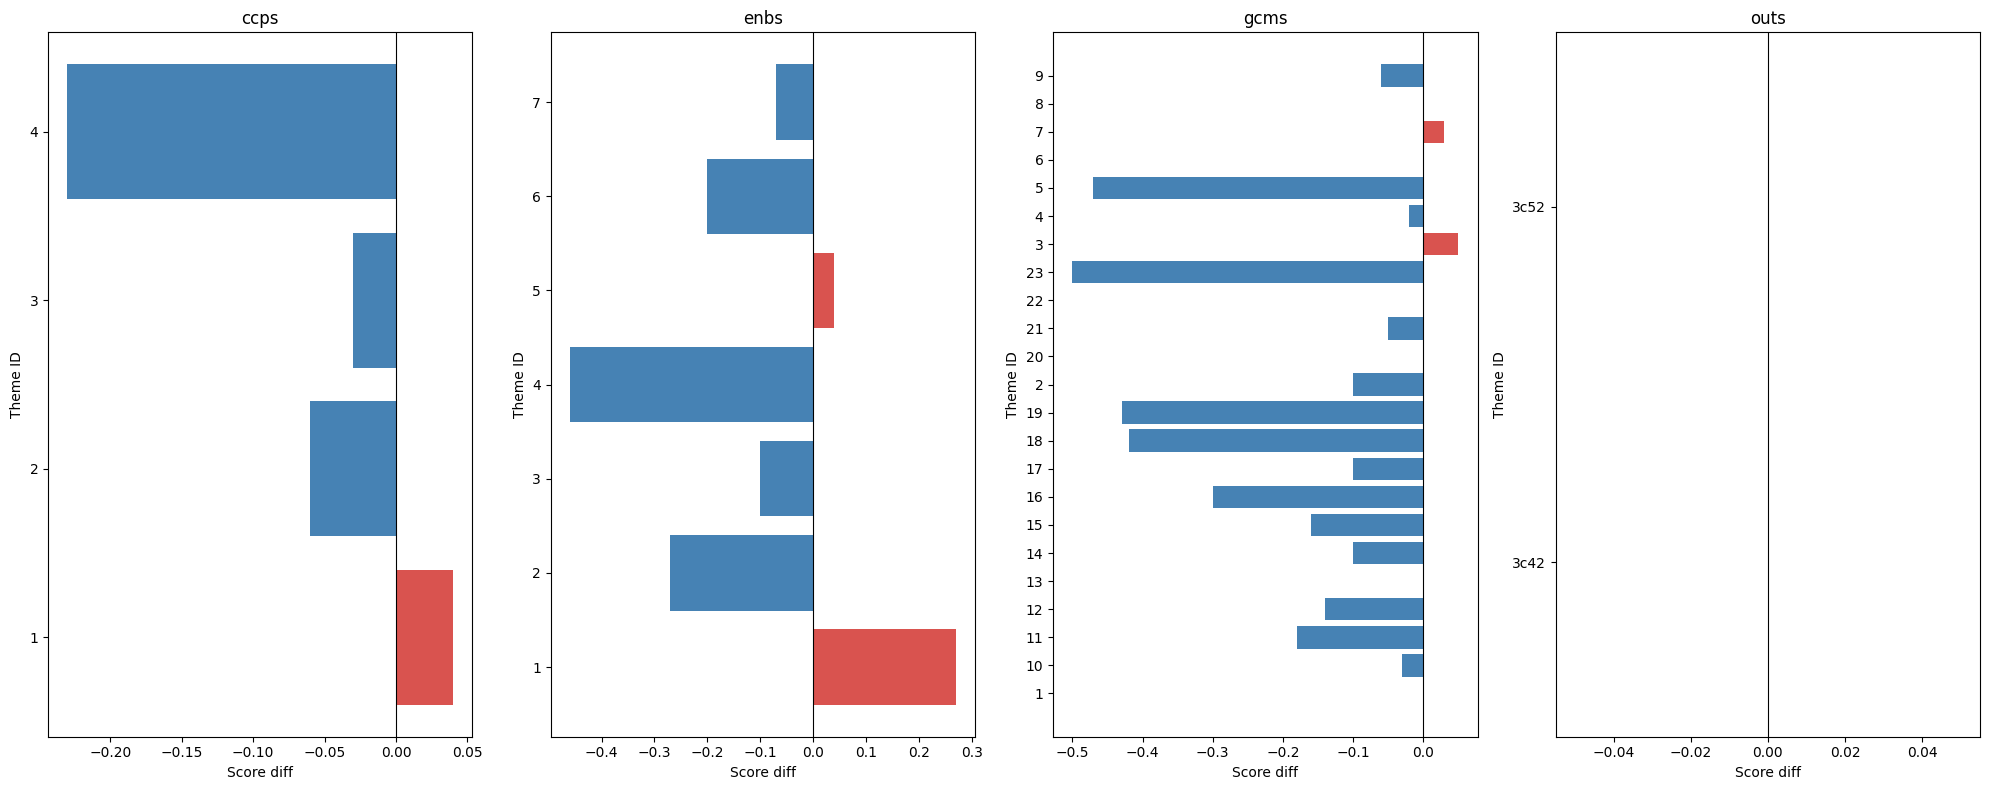

In [ ]:
plot_score_diffs_bar(dfs[dfs.evl_id == '0d4309b702e00faac631be8d609934ce'])

In [ ]:
def plot_rank_changes(df):
    "Slope chart of rank changes (old → new) per mapping type, coloured by direction"
    fig, axes = plt.subplots(1, df.mapping_type.nunique(), figsize=(20, 8), sharey=False)
    for ax, (mt, grp) in zip(axes, df.groupby('mapping_type')):
        for _, row in grp.iterrows():
            color = 'steelblue' if row.rank_diff < 0 else '#d9534f' if row.rank_diff > 0 else 'grey'
            ax.plot([0, 1], [row.rank_old, row.rank_new], marker='o', color=color, alpha=0.7)
            ax.text(0.5, (row.rank_old + row.rank_new) / 2 + (-0.15 * row.rank_diff), row.theme_id,
                    ha='center', va='center', fontsize=8, fontweight='bold', color=color,
                    path_effects=[withStroke(linewidth=3, foreground='white')])
        ax.set_xticks([0, 1])
        ax.set_xticklabels(['Old', 'New'], fontsize=12)
        ax.invert_yaxis()
        ax.yaxis.set_major_locator(plt.MaxNLocator(integer=True))
        ax.set_title(mt, fontsize=14, fontweight='bold')
        ax.set_ylabel('Rank', fontsize=12)
    plt.tight_layout()
    plt.show()

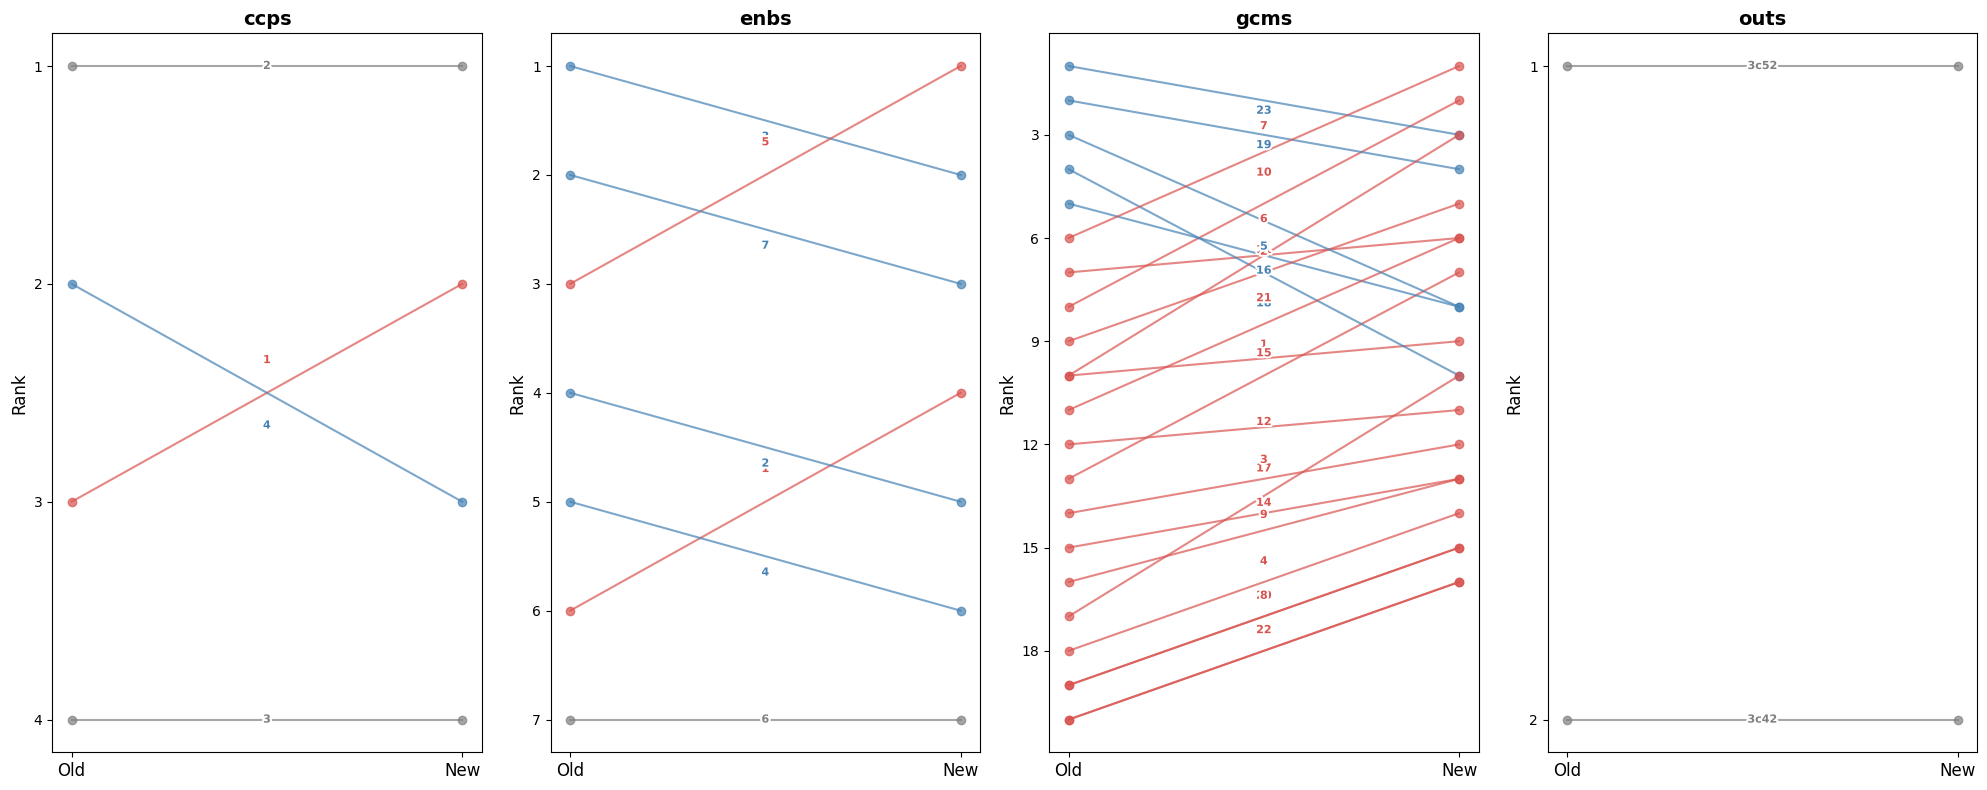

In [ ]:
plot_rank_changes(dfs[dfs.evl_id == '0d4309b702e00faac631be8d609934ce'])

### All

In [ ]:
def plot_score_diffs(dfs, mapping_type, xlabel='Theme', col='score_diff'):
    "Violin plot of score diffs (new − old) per theme for a given mapping type"
    d = dfs[dfs.mapping_type==mapping_type].copy()
    d['theme_id'] = d['theme_id'].astype(int)
    d = d.sort_values('theme_id')
    f, ax = plt.subplots(figsize=(14, 6))
    sns.violinplot(data=d, x='theme_id', y=col, hue='theme_id', legend=False, bw_adjust=.5, cut=1, linewidth=1, palette="Set3")
    ax.axhline(0, color='red', linewidth=0.8, linestyle='--')
    ax.set(xlabel=xlabel, ylabel=f'{col} (new − old)', title=mapping_type)
    sns.despine(left=True, bottom=True)
    plt.tight_layout()

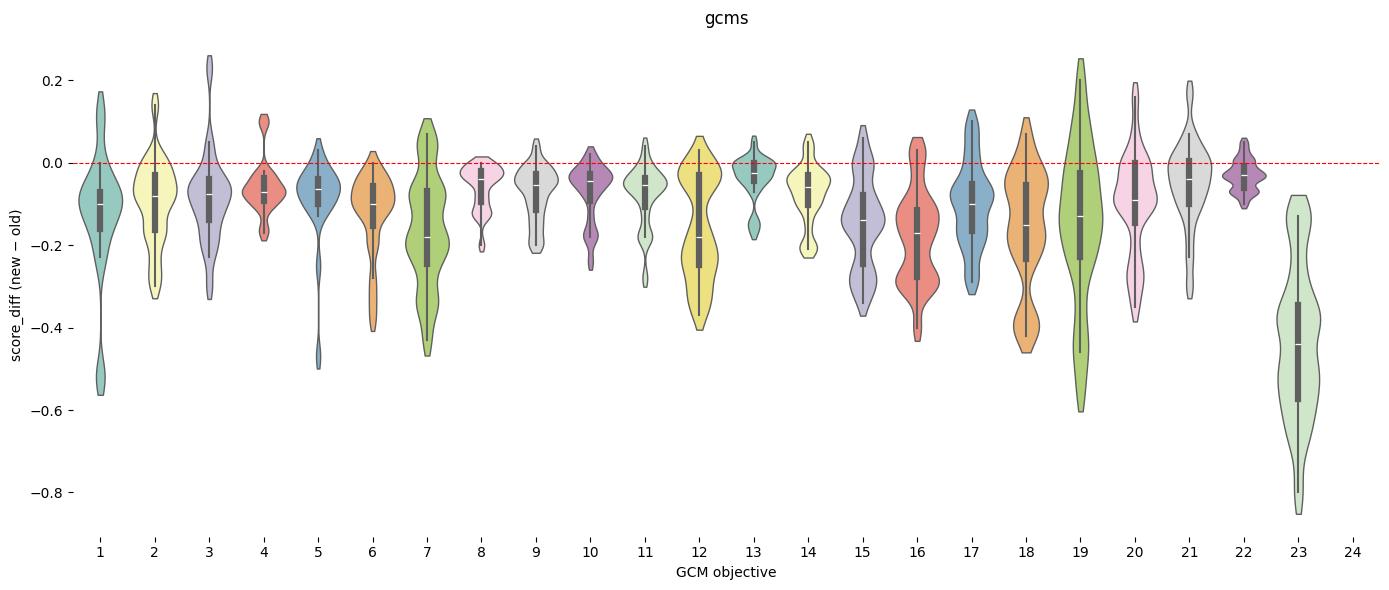

In [ ]:
plot_score_diffs(dfs, 'gcms', 'GCM objective')

## Reporting

In [ ]:
import contextkit.read as rd

In [ ]:
dh_doc = rd.read_text('https://answerdotai.github.io/dialoghelper/core.html.md')
print(dh_doc[:200])

# dialoghelper


<!-- WARNING: THIS FILE WAS AUTOGENERATED! DO NOT EDIT! -->

``` python
from dialoghelper import *
```

``` python
from fastcore import tools
from fastcore.test import *
```

## Helpe


- how to create a nb via dialogheper?
- how to create a cell?
- nice markdown template
- what to put in?
    - overview
    - explaining what has been changed 
    - title
    - rank changed
    - score changed
    - for top ranked (top 2) items changed
        - previous reasoning
        - new reasoning


In [ ]:
from dialoghelper.stdtools import *

In [ ]:
find_dname()

'/iomeval/nbs/processing/changes/changes_analysis'

In [ ]:
await create_or_run_dialog('test_dialog')

{'success': '"iomeval/nbs/processing/changes/test_dialog" is now running'}

In [ ]:
_id = await add_msg('testing', dname='test_dialog')

In [ ]:
_id

'_e699dd4b'

## Analysis

### Top rank changed

In [ ]:
def top_theme(dfs, rank_col): return dfs[dfs[rank_col]==1].set_index(['evl_id','mapping_type'])['theme_id']

In [ ]:
top_old = top_theme(dfs, 'rank_old')
top_new = top_theme(dfs, 'rank_new')
top_changed = (top_old != top_new).rename('changed')
top_changed.groupby('mapping_type').mean().mul(100).round(1).rename('% reports where top theme changed')

mapping_type
ccps    20.0
enbs    55.0
gcms    25.0
outs    20.0
Name: % reports where top theme changed, dtype: float64

In [ ]:
top_changed

evl_id                            mapping_type
8dd2261100ff5d714e73b411eed043d5  ccps            False
                                  enbs             True
                                  gcms            False
                                  outs            False
1d7e6d2d445145d1d350b48b72b36681  ccps            False
                                                  ...  
4c04ec0d3e651f7616190c6fc2dcfc18  outs            False
e21305a89aeb76fafa8f4270392d463a  ccps            False
                                  enbs             True
                                  gcms             True
                                  outs             True
Name: changed, Length: 80, dtype: bool

In [ ]:
top_changed[top_changed].xs('enbs', level='mapping_type')

evl_id
8dd2261100ff5d714e73b411eed043d5    True
1d7e6d2d445145d1d350b48b72b36681    True
760568a15e144bcfb88dbbd50247dc51    True
316c47c9dc19c820f3217434d4b93b28    True
0d4309b702e00faac631be8d609934ce    True
e8d9427f4a9094f68e17307faa567d8b    True
75bad4665ed458cce78740e3d86f72d0    True
f409b3f9a0671ec69a8591c425a45c1d    True
a493c447cff3e03ca94024335d5c5c7a    True
06fd0949dc874f388686461c19d2669c    True
e21305a89aeb76fafa8f4270392d463a    True
Name: changed, dtype: bool

In [ ]:
gcms_top_changed = top_changed[top_changed].xs('gcms', level='mapping_type')
gcms_top_changedc

evl_id
760568a15e144bcfb88dbbd50247dc51    True
22cac1c000836253adc445993e101560    True
316c47c9dc19c820f3217434d4b93b28    True
0d4309b702e00faac631be8d609934ce    True
e21305a89aeb76fafa8f4270392d463a    True
Name: changed, dtype: bool

In [ ]:
[lut_id_staff[i] for i in gcms_top_changed.index if i in lut_id_staff]

['Andres', 'Davide', 'elma', 'pip', 'pip']

In [ ]:
enbs_top_changed = top_changed[top_changed].xs('enbs', level='mapping_type')
enbs_top_changed


evl_id
8dd2261100ff5d714e73b411eed043d5    True
1d7e6d2d445145d1d350b48b72b36681    True
760568a15e144bcfb88dbbd50247dc51    True
316c47c9dc19c820f3217434d4b93b28    True
0d4309b702e00faac631be8d609934ce    True
e8d9427f4a9094f68e17307faa567d8b    True
75bad4665ed458cce78740e3d86f72d0    True
f409b3f9a0671ec69a8591c425a45c1d    True
a493c447cff3e03ca94024335d5c5c7a    True
06fd0949dc874f388686461c19d2669c    True
e21305a89aeb76fafa8f4270392d463a    True
Name: changed, dtype: bool

In [ ]:
[lut_id_staff[i] for i in enbs_top_changed.index if i in lut_id_staff]

['rogers',
 'rogers',
 'Andres',
 'elma',
 'pip',
 'Davide',
 'Andres',
 'Andres',
 'Davide',
 'Davide',
 'pip']

In [ ]:
ccps_top_changed = top_changed[top_changed].xs('ccps', level='mapping_type')
ccps_top_changed


evl_id
22cac1c000836253adc445993e101560    True
dba9eb1220368d28682d8531108e767d    True
891448b7a4bf12763ea0579dd67e289d    True
4c04ec0d3e651f7616190c6fc2dcfc18    True
Name: changed, dtype: bool

In [ ]:
[lut_id_staff[i] for i in ccps_top_changed.index if i in lut_id_staff]

['Davide', 'rogers', 'Andres', 'Andres']

- how much it changed?
- We are mostly interested in the themes id previously highly ranked and now ranked lower. I don't want to overload domain experts with all changes

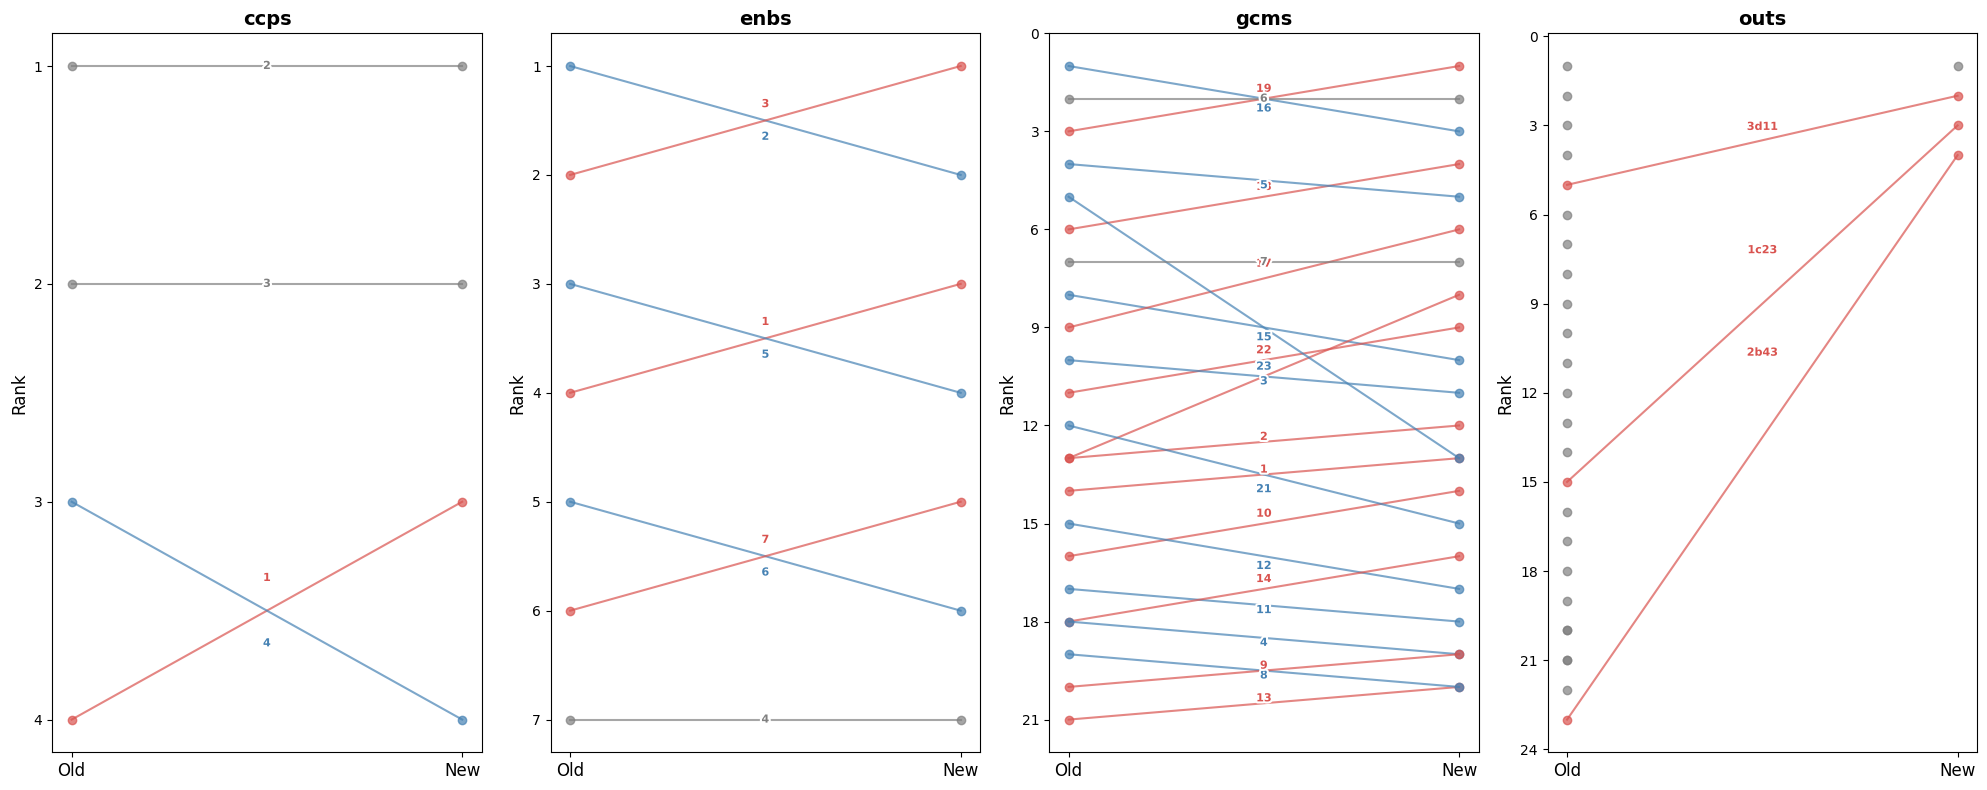

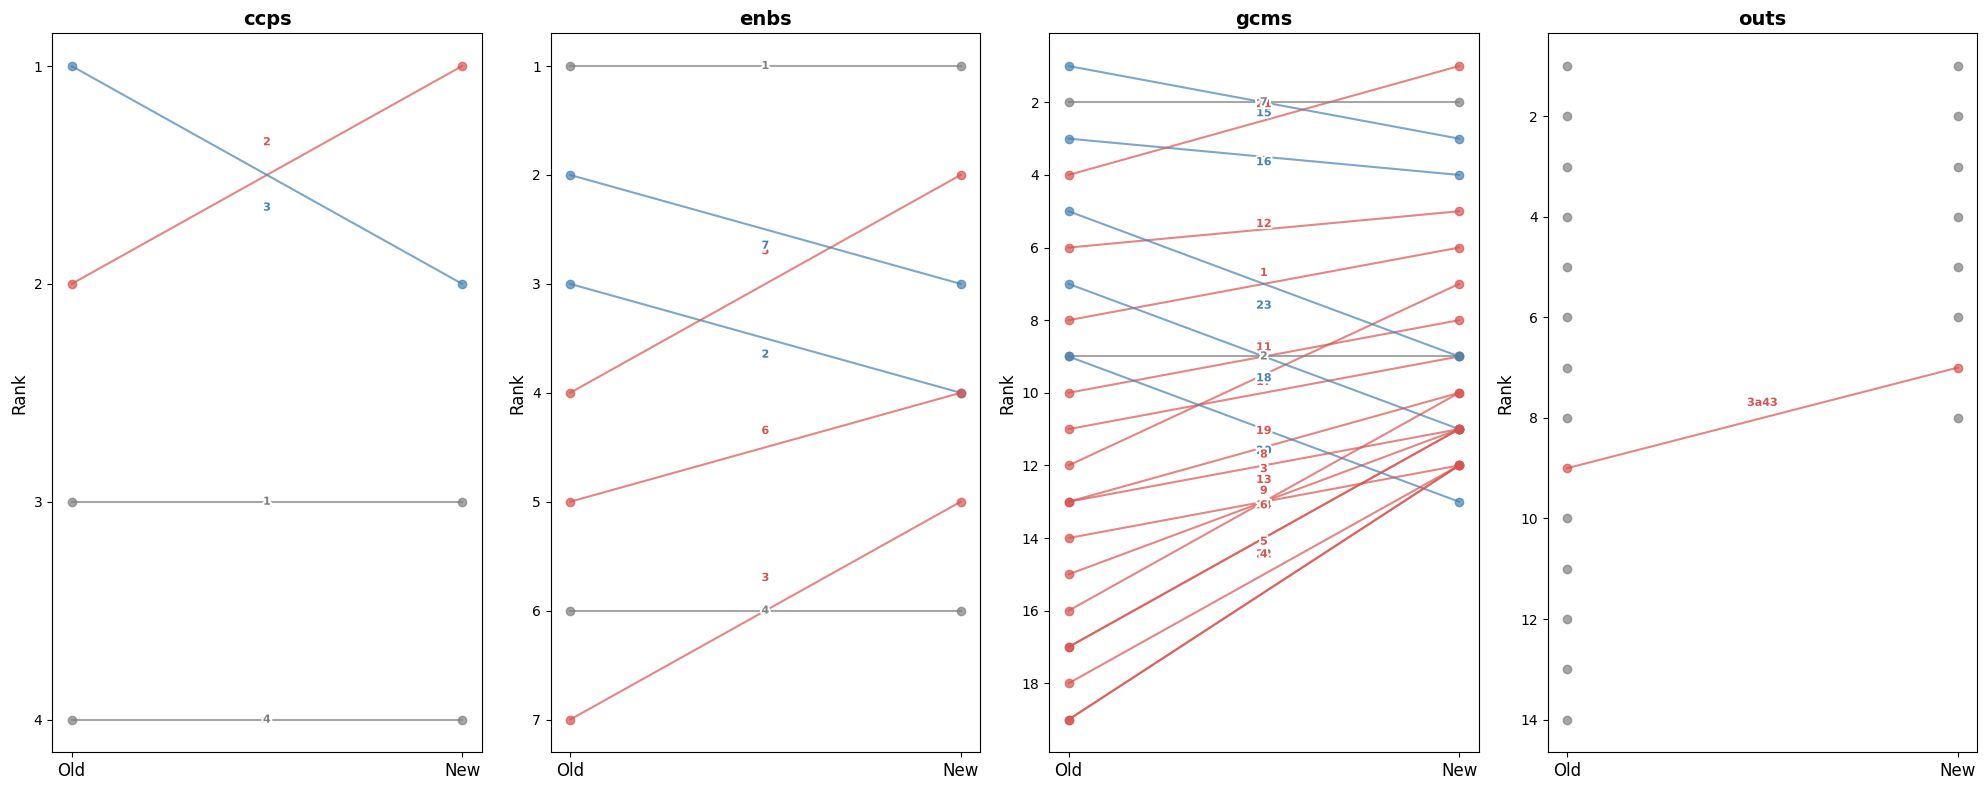

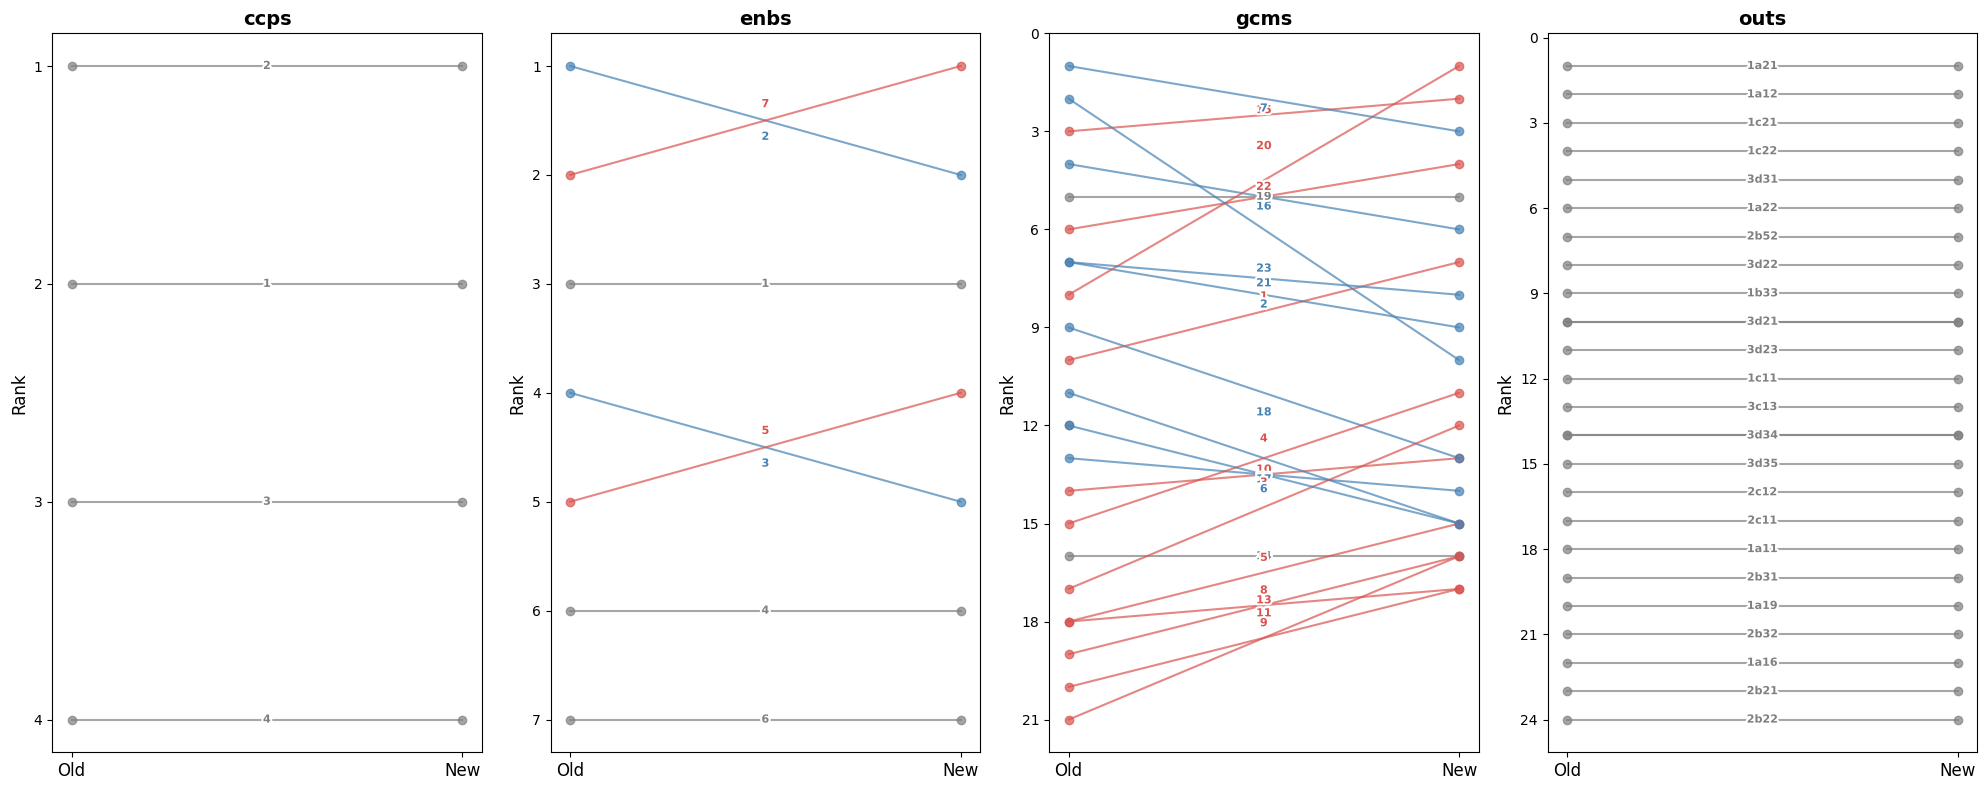

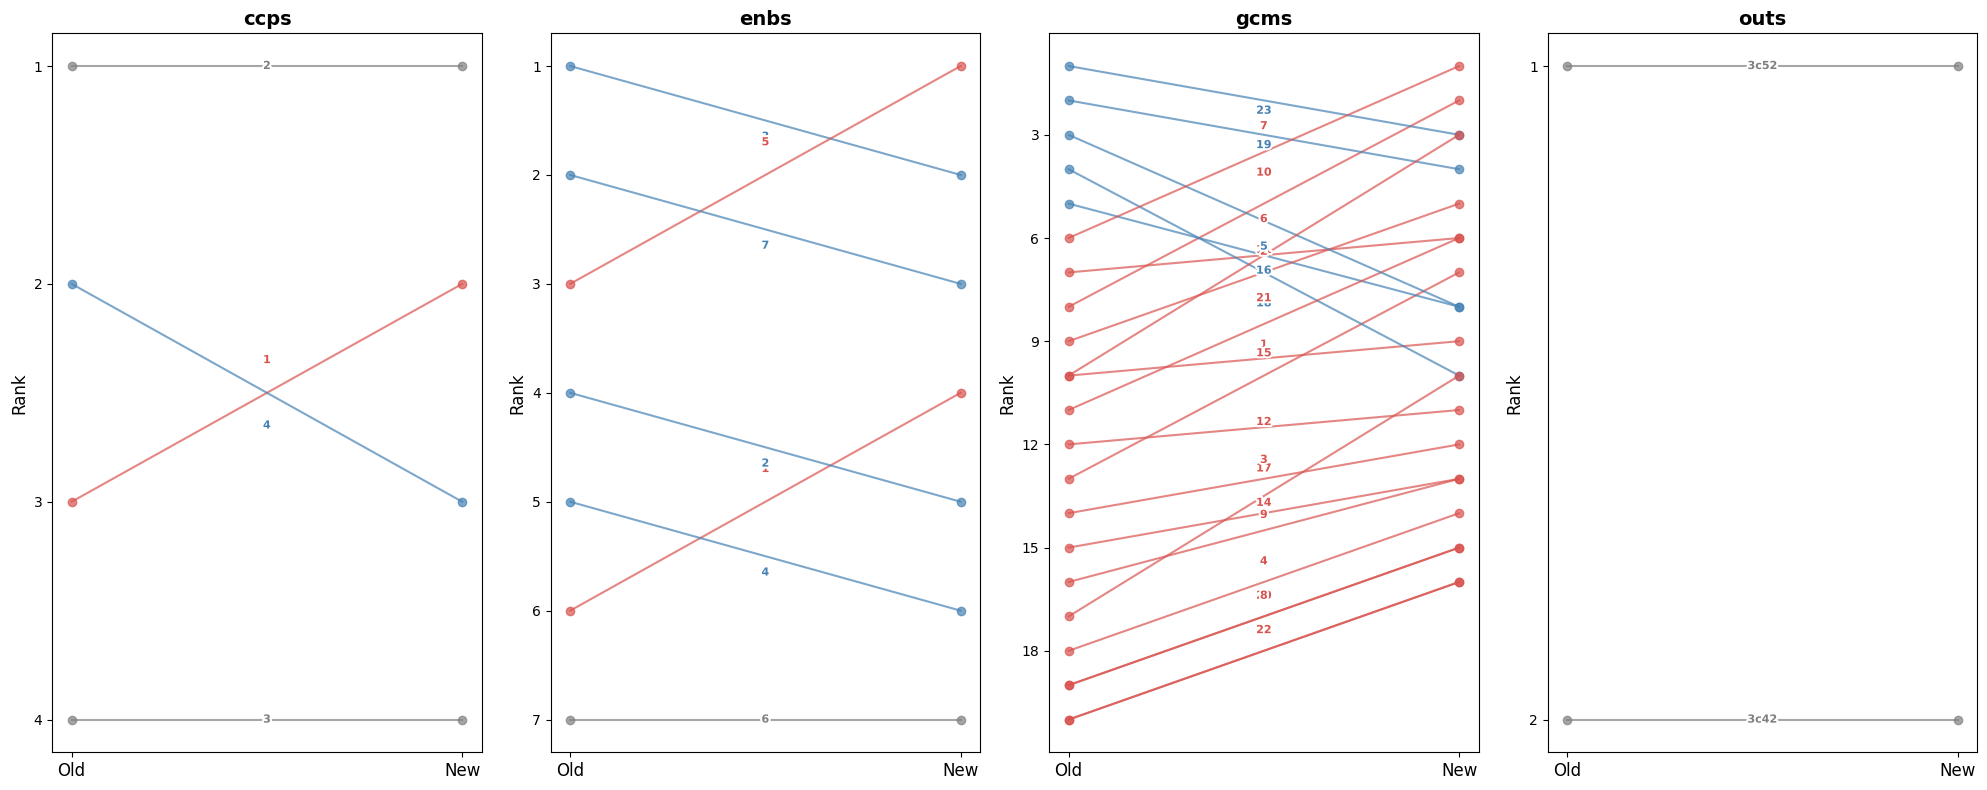

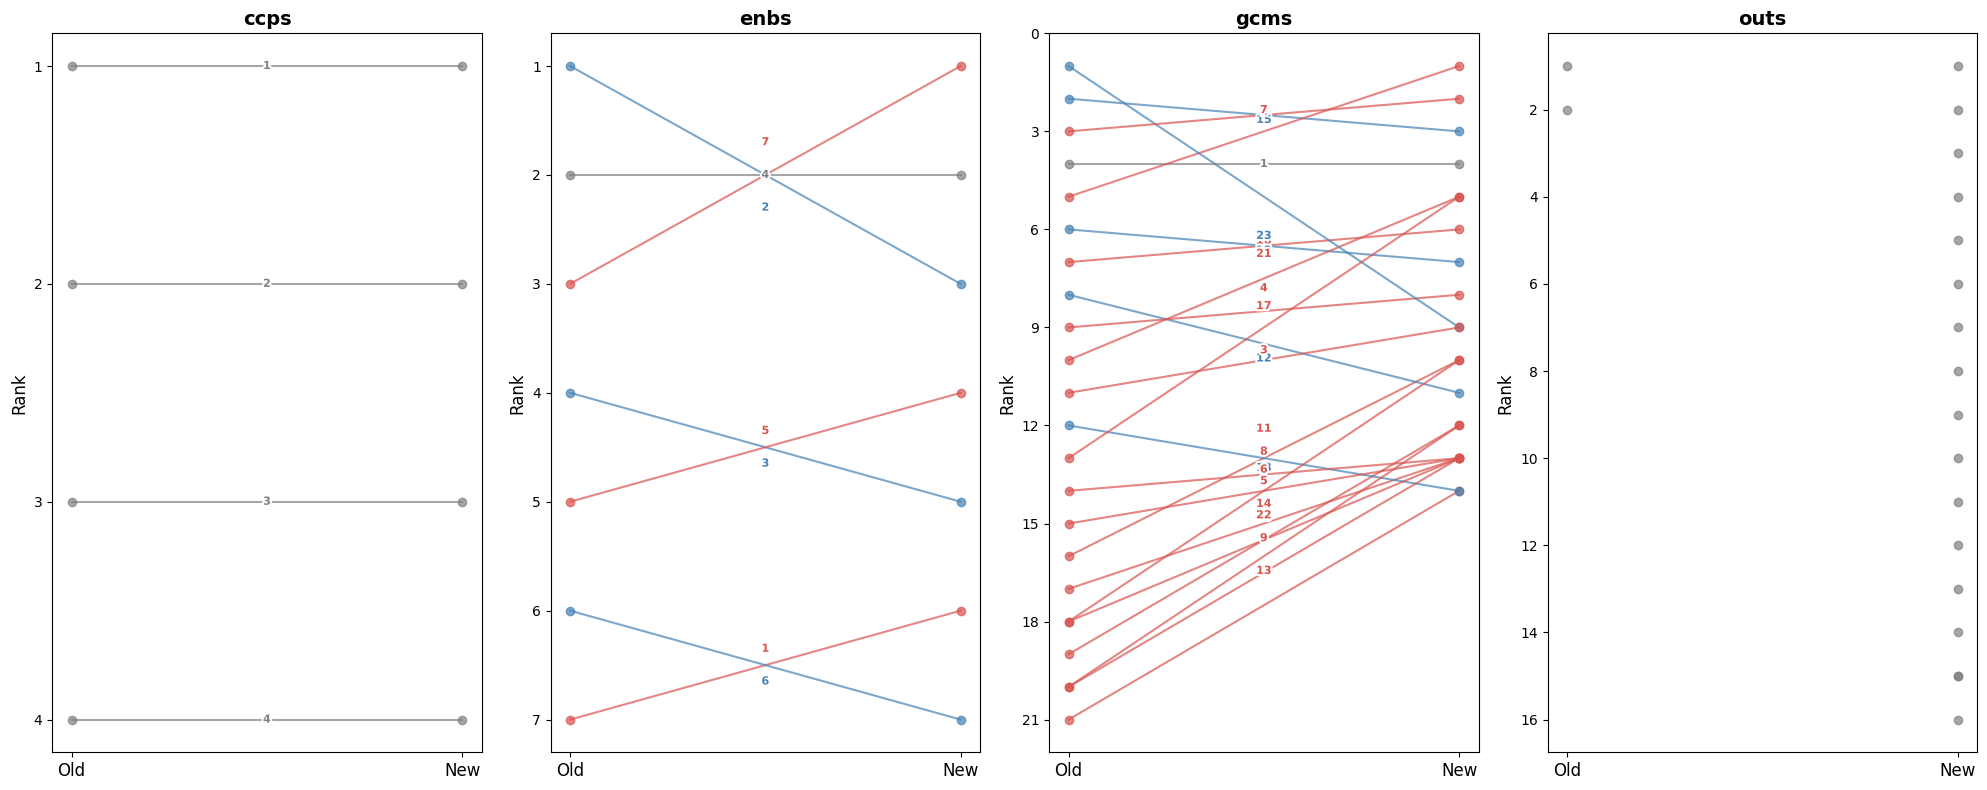

In [ ]:
for i in gcms_top_changed.index: 
    plot_rank_changes(dfs[dfs.evl_id == i])
    #print(i)

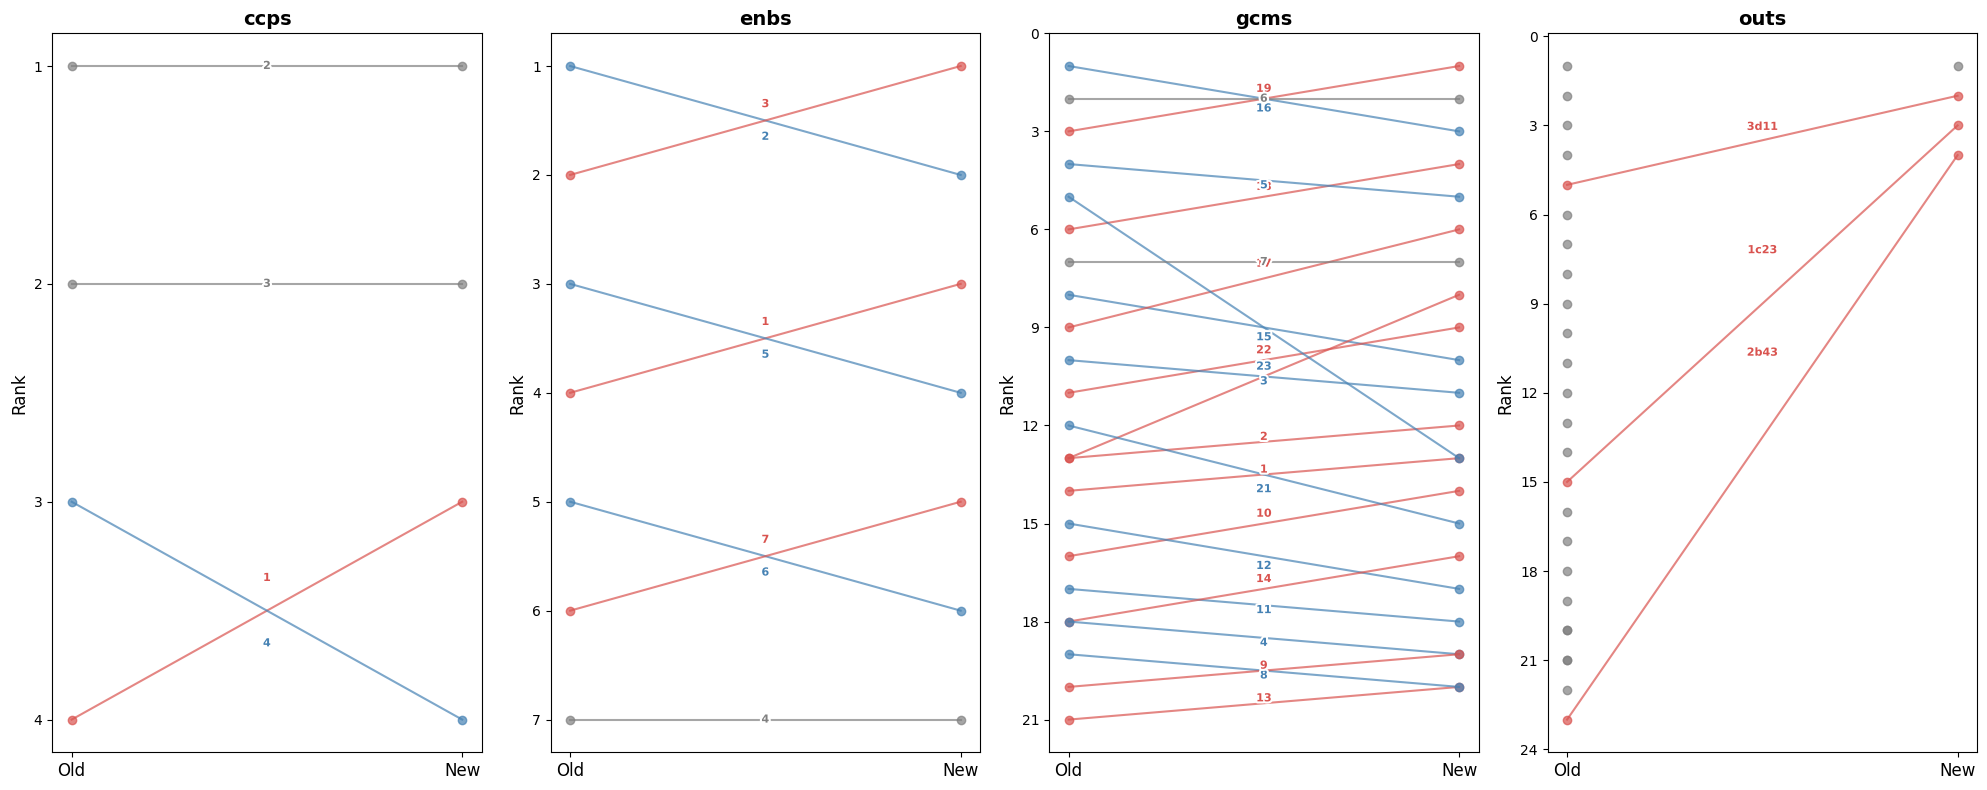

In [ ]:
plot_rank_changes(dfs[dfs.evl_id == '760568a15e144bcfb88dbbd50247dc51'])

In [ ]:
q = 'mapping_type == "gcms" and evl_id == "760568a15e144bcfb88dbbd50247dc51"'
print(dfs.query(q)[['mapping_type', 'theme_id', 'score_old', 'score_new', 'rank_old', 'rank_new']])
info_evl('760568a15e144bcfb88dbbd50247dc51')

    mapping_type theme_id  score_old  score_new  rank_old  rank_new
97          gcms        1       0.28       0.20      14.0      13.0
98          gcms       10       0.22       0.18      16.0      14.0
99          gcms       11       0.18       0.05      17.0      18.0
100         gcms       12       0.25       0.06      15.0      17.0
101         gcms       13       0.05       0.03      21.0      20.0
102         gcms       14       0.15       0.08      18.0      16.0
103         gcms       15       0.48       0.30       8.0      10.0
104         gcms       16       0.91       0.82       1.0       3.0
105         gcms       17       0.45       0.55       9.0       6.0
106         gcms       18       0.58       0.65       6.0       4.0
107         gcms       19       0.85       0.88       3.0       1.0
108         gcms        2       0.31       0.22      13.0      12.0
109         gcms       20       0.31       0.38      13.0       8.0
110         gcms       21       0.32       0.15 


### THEMATIC EVALUATION OF IOM'S LABOUR MIGRATION AND MOBILITY STRATEGY AND INITIATIVES
**Year:** 2023 | **Organization:** IOM | **Countries:** Worldwide

**Documents:** 5 available  
**ID:** `760568a15e144bcfb88dbbd50247dc51`


In [ ]:
print(dfs[dfs.evl_id == '760568a15e144bcfb88dbbd50247dc51'][['mapping_type', 'theme_id', 'rank_old', 'rank_new', 'rank_diff']].query('mapping_type == "gcms"'))

    mapping_type theme_id  rank_old  rank_new  rank_diff
97          gcms        1      14.0      13.0        1.0
98          gcms       10      16.0       NaN        NaN
99          gcms       10       NaN      14.0        NaN
100         gcms       11      17.0       NaN        NaN
101         gcms       11       NaN      18.0        NaN
102         gcms       12      15.0       NaN        NaN
103         gcms       12       NaN      17.0        NaN
104         gcms       13      21.0       NaN        NaN
105         gcms       13       NaN      20.0        NaN
106         gcms       14      18.0       NaN        NaN
107         gcms       14       NaN      16.0        NaN
108         gcms       15       8.0      10.0       -2.0
109         gcms       16       1.0       NaN        NaN
110         gcms       16       NaN       3.0        NaN
111         gcms       17       9.0       NaN        NaN
112         gcms       17       NaN       6.0        NaN
113         gcms       18      

In [ ]:
for rpt in r
plot_rank_changes(dfs[dfs.evl_id == '0d4309b702e00faac631be8d609934ce'])

In [ ]:
top_changed[top_changed].xs('enbs', level='mapping_type')

evl_id
8dd2261100ff5d714e73b411eed043d5    True
1d7e6d2d445145d1d350b48b72b36681    True
760568a15e144bcfb88dbbd50247dc51    True
316c47c9dc19c820f3217434d4b93b28    True
0d4309b702e00faac631be8d609934ce    True
e8d9427f4a9094f68e17307faa567d8b    True
75bad4665ed458cce78740e3d86f72d0    True
f409b3f9a0671ec69a8591c425a45c1d    True
a493c447cff3e03ca94024335d5c5c7a    True
06fd0949dc874f388686461c19d2669c    True
e21305a89aeb76fafa8f4270392d463a    True
Name: changed, dtype: bool

In [ ]:
top_changed[top_changed].xs('ccps', level='mapping_type')

evl_id
22cac1c000836253adc445993e101560    True
dba9eb1220368d28682d8531108e767d    True
891448b7a4bf12763ea0579dd67e289d    True
4c04ec0d3e651f7616190c6fc2dcfc18    True
Name: changed, dtype: bool

In [ ]:
#top_changed[top_changed].reset_index().query("mapping_type == 'enbs'")

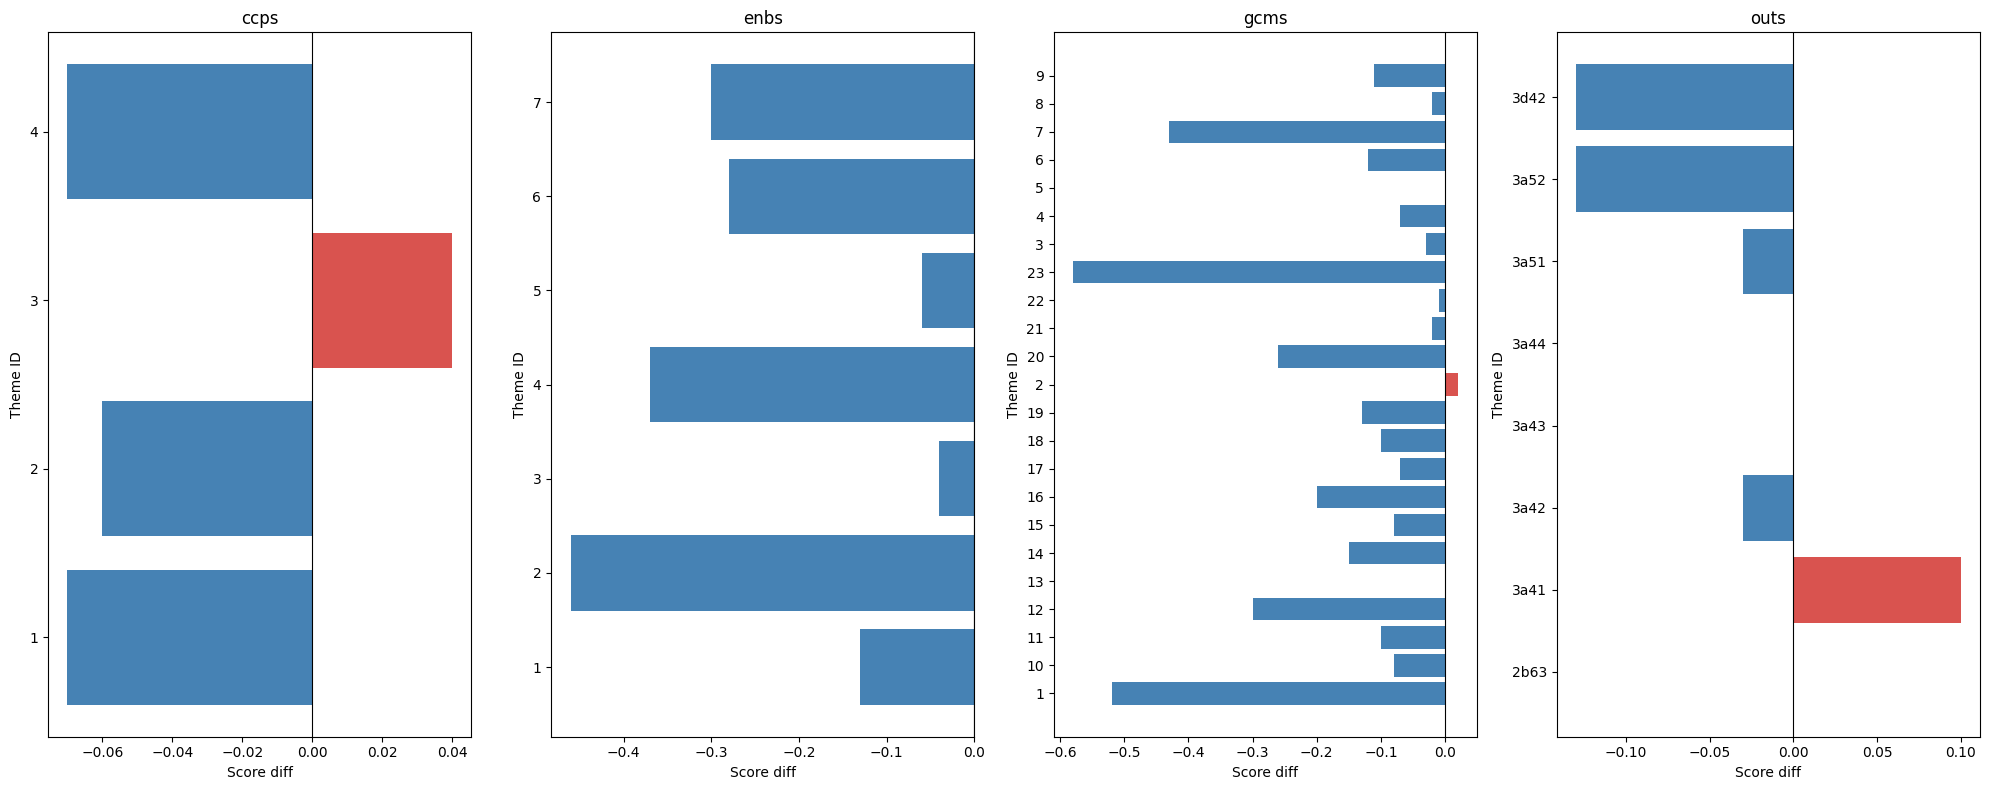

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, df.mapping_type.nunique(), figsize=(20, 8), sharey=False)
for ax, (mt, grp) in zip(axes, df.groupby('mapping_type')):
    colors = ['#d9534f' if x > 0 else 'steelblue' for x in grp.score_diff]
    ax.barh(grp.theme_id.astype(str), grp.score_diff, color=colors)
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_title(mt)
    ax.set_xlabel('Score diff')
    ax.set_ylabel('Theme ID')
plt.tight_layout()
plt.show()

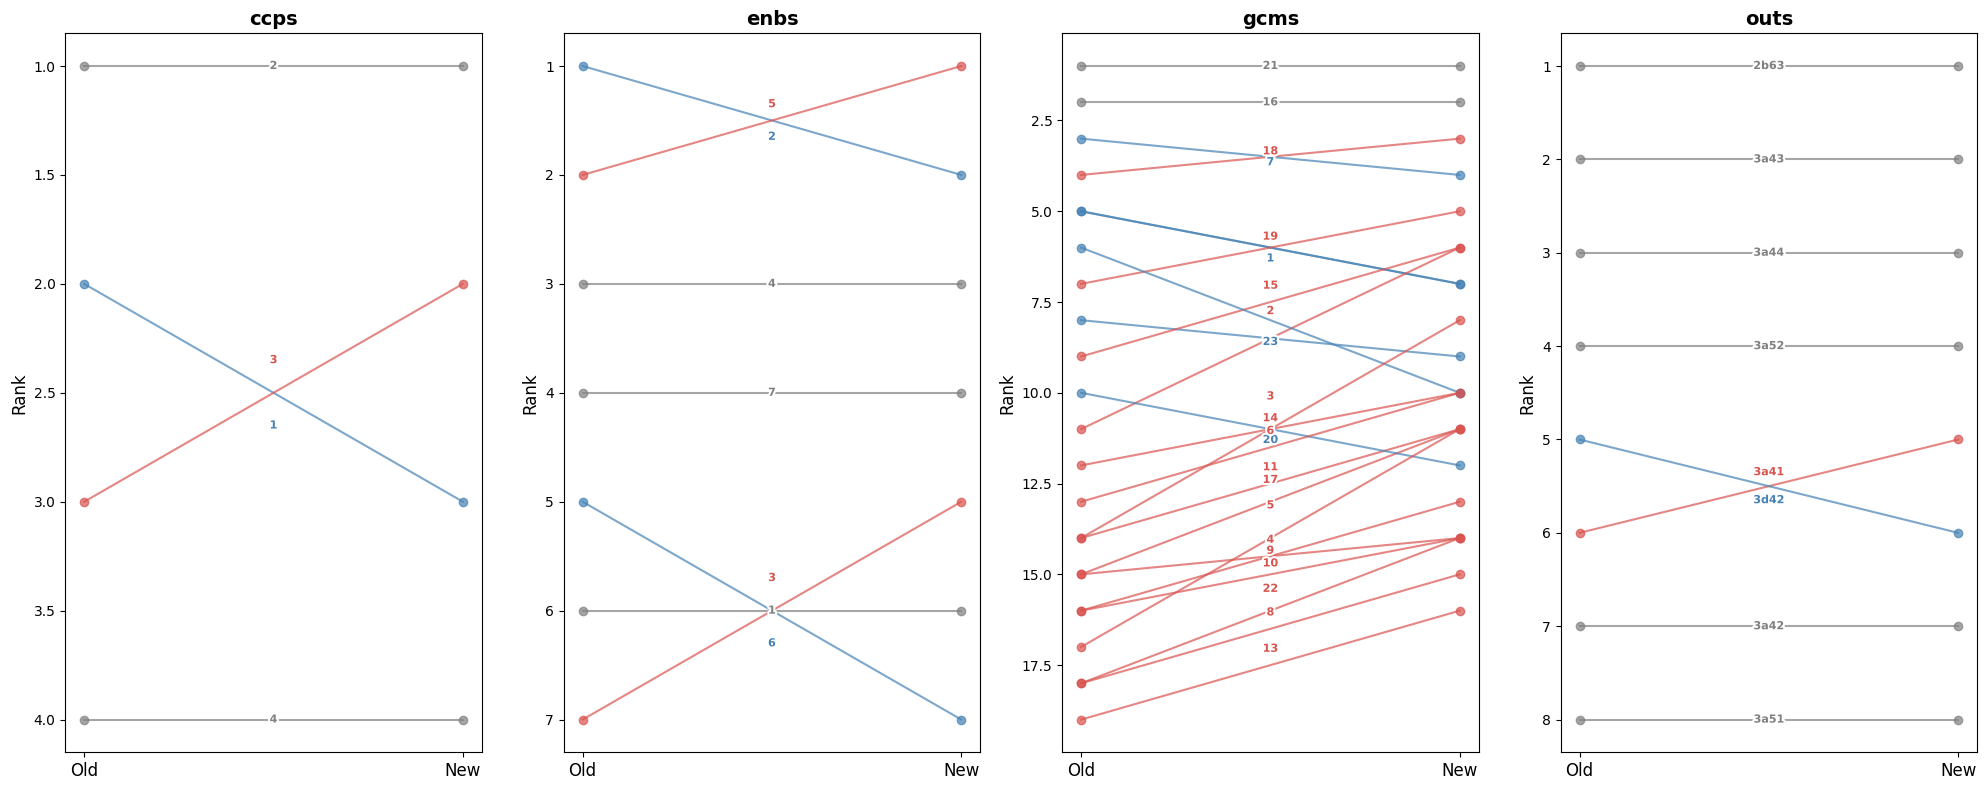

In [ ]:
from matplotlib.patheffects import withStroke

fig, axes = plt.subplots(1, df.mapping_type.nunique(), figsize=(20, 8), sharey=False)
for ax, (mt, grp) in zip(axes, df.groupby('mapping_type')):
    for _, row in grp.iterrows():
        color = 'steelblue' if row.rank_diff < 0 else '#d9534f' if row.rank_diff > 0 else 'grey'
        ax.plot([0, 1], [row.rank_old, row.rank_new], marker='o', color=color, alpha=0.7)
        mid_y = (row.rank_old + row.rank_new) / 2
        offset = -0.15 * row.rank_diff
        ax.text(0.5, mid_y + offset, row.theme_id, ha='center', va='center', fontsize=8, fontweight='bold',
                color=color, path_effects=[withStroke(linewidth=3, foreground='white')])
    ax.set_xticks([0, 1])
    ax.set_xticklabels(['Old', 'New'], fontsize=12)
    ax.invert_yaxis()
    ax.set_title(mt, fontsize=14, fontweight='bold')
    ax.set_ylabel('Rank', fontsize=12)
plt.tight_layout()
plt.show()

I've remapped all $`current_res` reports, so I can compare mappings for all of them. What kind of questions could we ask?
- "does GCM 23 systematically get lower rank on average?"

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠

Great starting point! Here are some useful directions:

**Systematic bias / directional shifts**
- Does a specific theme (e.g. GCM 23) consistently score lower / rank lower across reports?
- Which themes show the most consistent direction of change (always up or always down)?
- Are score drops concentrated in specific mapping types (e.g. `gcms` more affected than `ccps`)?

**Magnitude of change**
- Which themes have the largest average `|score_diff|` across reports?
- What's the distribution of `pct_change` — are most changes small noise or substantial?
- Are there outlier reports where changes are much larger than average?

**Rank stability**
- Which themes are most rank-stable (low variance in `rank_diff`) across reports?
- How often does the top-ranked theme change between old and new?

**Report-level**
- Which reports changed the most overall (e.g. mean `|score_diff|` per report)?
- Are there reports where the set of "high relevance" themes (e.g. score > 0.5) changed substantially?

**Cross-mapping consistency**
- Do reports that show a big drop in a GCM theme also show a drop in the related SRF output?

---

Your GCM 23 question is a good one to start with — it's essentially: *across all reports, what is the mean `rank_diff` for GCM 23?* Shall I write that up, along with a small summary table for all themes?

In [ ]:
df = compare_mappings(current_res[0], DATA_PATH/'results', LATEST_TAG_PATH).pipe(add_diffs).pipe(add_ranks).pipe(add_pct_change)
df.head()

,mapping_type,theme_id,theme_title_x,score_old,theme_title_y,score_new,score_diff,is_new,is_dropped,rank_old,rank_new,rank_diff,pct_change
0,ccps,1,"Integrity, Transparency and Accountability",0.45,"Integrity, Transparency and Accountability",0.38,-0.07,False,False,2.0,3.0,-1.0,-15.555556
1,ccps,2,"Equality, Diversity & Inclusion",0.72,"Equality, Diversity & Inclusion",0.66,-0.06,False,False,1.0,1.0,0.0,-8.333333
2,ccps,3,Protection-centred,0.38,Protection-centred,0.42,0.04,False,False,3.0,2.0,1.0,10.526316
3,ccps,4,Environmental Sustainability,0.12,Environmental Sustainability,0.05,-0.07,False,False,4.0,4.0,0.0,-58.333333
4,enbs,1,Workforce,0.28,Workforce,0.15,-0.13,False,False,6.0,6.0,0.0,-46.428571


In [ ]:
dfs = pd.concat([
    compare_mappings(
        d, 
        DATA_PATH/'results', 
        LATEST_TAG_PATH).pipe(add_diffs).pipe(add_ranks).pipe(add_pct_change) 
    for d in current_res])

In [ ]:
dfs = pd.concat([
    compare_mappings(d, DATA_PATH/'results', LATEST_TAG_PATH).pipe(add_diffs).pipe(add_ranks).pipe(add_pct_change)
    for d in current_res], ignore_index=True)

In [ ]:
dfs.head()

,mapping_type,theme_id,theme_title_x,score_old,theme_title_y,score_new,score_diff,is_new,is_dropped,rank_old,rank_new,rank_diff,pct_change
0,ccps,1,"Integrity, Transparency and Accountability",0.45,"Integrity, Transparency and Accountability",0.38,-0.07,False,False,2.0,3.0,-1.0,-15.555556
1,ccps,2,"Equality, Diversity & Inclusion",0.72,"Equality, Diversity & Inclusion",0.66,-0.06,False,False,1.0,1.0,0.0,-8.333333
2,ccps,3,Protection-centred,0.38,Protection-centred,0.42,0.04,False,False,3.0,2.0,1.0,10.526316
3,ccps,4,Environmental Sustainability,0.12,Environmental Sustainability,0.05,-0.07,False,False,4.0,4.0,0.0,-58.333333
4,enbs,1,Workforce,0.28,Workforce,0.15,-0.13,False,False,6.0,6.0,0.0,-46.428571


In [ ]:
dfs[(dfs.mapping_type=='gcms') & (dfs.theme_id=='23')]['pct_change'].describe()

count    20.000000
mean    -65.511802
std      23.376751
min     -86.956522
25%     -79.801829
50%     -74.264706
75%     -61.572967
max     -15.294118
Name: pct_change, dtype: float64

In [ ]:
dfs[(dfs.mapping_type=='gcms') & (dfs.theme_id=='23')].score_diff.describe()

count    20.000000
mean     -0.435000
std       0.188582
min      -0.800000
25%      -0.572500
50%      -0.440000
75%      -0.345000
max      -0.130000
Name: score_diff, dtype: float64

### Scores diff

<Axes: >

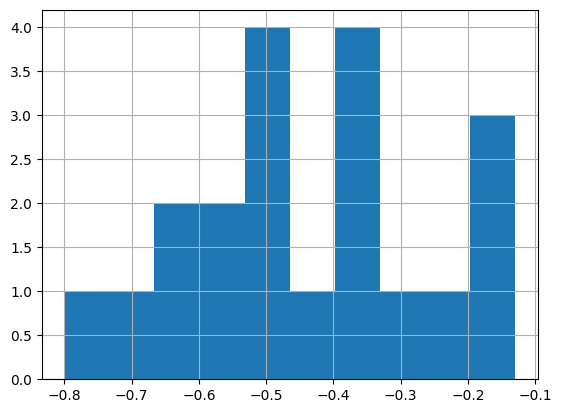

In [ ]:
dfs[(dfs.mapping_type=='gcms') & (dfs.theme_id=='23')].score_diff.hist()

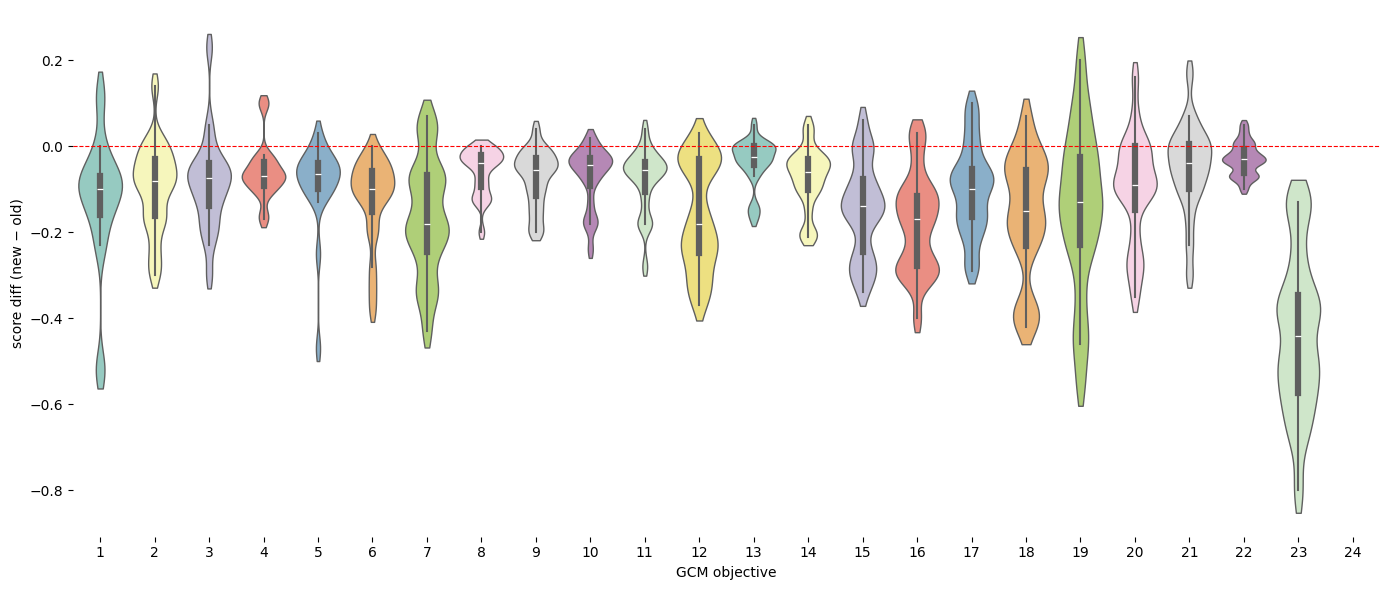

In [ ]:
import seaborn as sns, matplotlib.pyplot as plt

gcm_dfs = dfs[dfs.mapping_type=='gcms'].copy()
gcm_dfs['theme_id'] = gcm_dfs['theme_id'].astype(int)
gcm_dfs = gcm_dfs.sort_values('theme_id')

f, ax = plt.subplots(figsize=(14, 6))
sns.violinplot(data=gcm_dfs, x='theme_id', y='score_diff', hue='theme_id', legend=False, bw_adjust=.5, cut=1, linewidth=1, palette="Set3")

ax.axhline(0, color='red', linewidth=0.8, linestyle='--')
ax.set(xlabel='GCM objective', ylabel='score diff (new − old)')
sns.despine(left=True, bottom=True)
plt.tight_layout()

In [ ]:
def plot_score_diffs(dfs, mapping_type, xlabel='Theme', col='score_diff'):
    "Violin plot of score diffs (new − old) per theme for a given mapping type"
    d = dfs[dfs.mapping_type==mapping_type].copy()
    d['theme_id'] = d['theme_id'].astype(int)
    d = d.sort_values('theme_id')
    f, ax = plt.subplots(figsize=(14, 6))
    sns.violinplot(data=d, x='theme_id', y=col, hue='theme_id', legend=False, bw_adjust=.5, cut=1, linewidth=1, palette="Set3")
    ax.axhline(0, color='red', linewidth=0.8, linestyle='--')
    ax.set(xlabel=xlabel, ylabel=f'{col} (new − old)', title=mapping_type)
    sns.despine(left=True, bottom=True)
    plt.tight_layout()

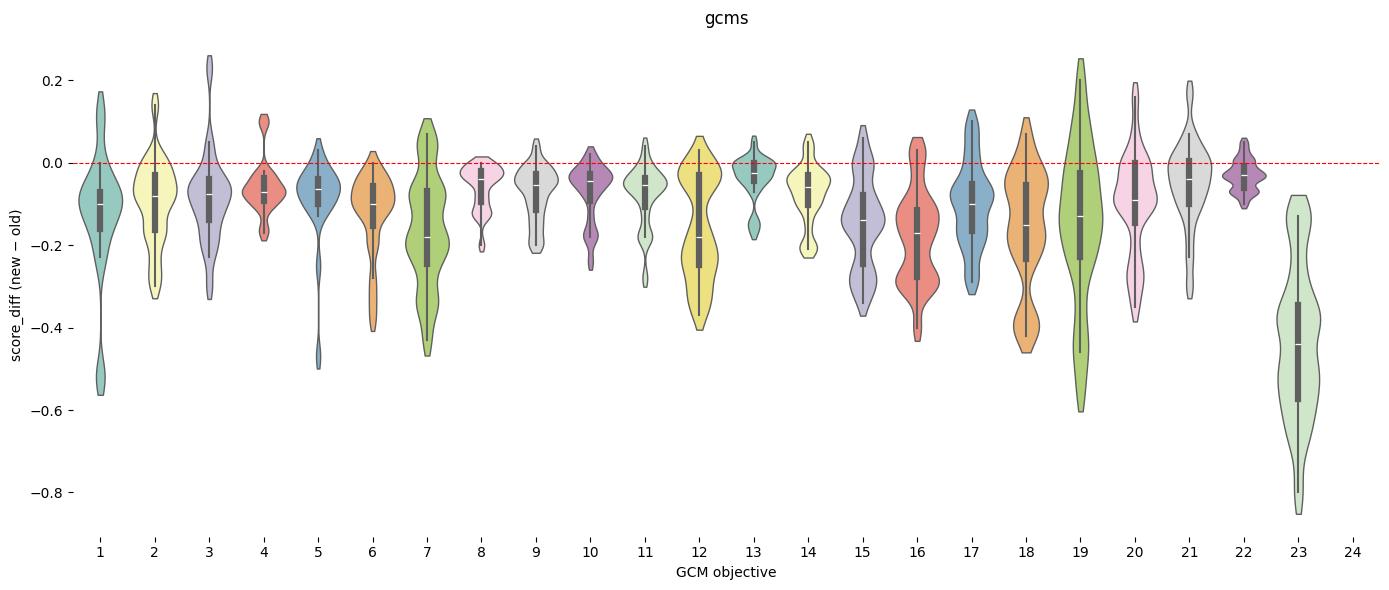

In [ ]:
plot_score_diffs(dfs, 'gcms', 'GCM objective')

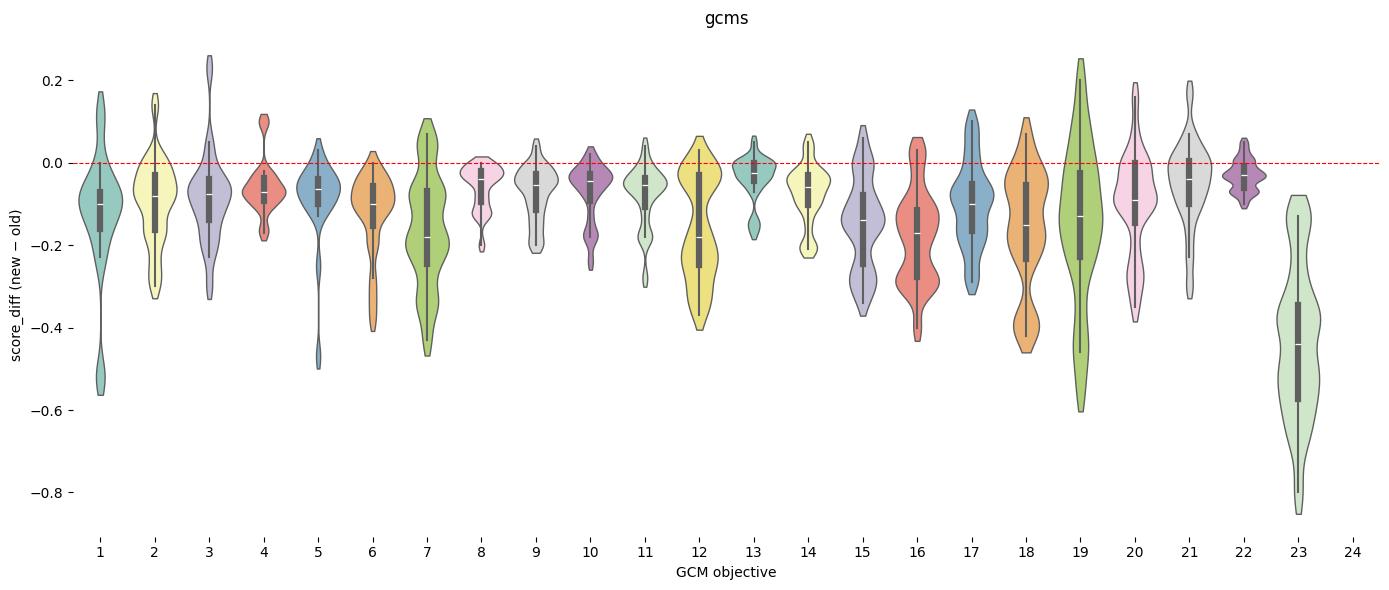

In [ ]:
plot_score_diffs(dfs, 'gcms', 'GCM objective')

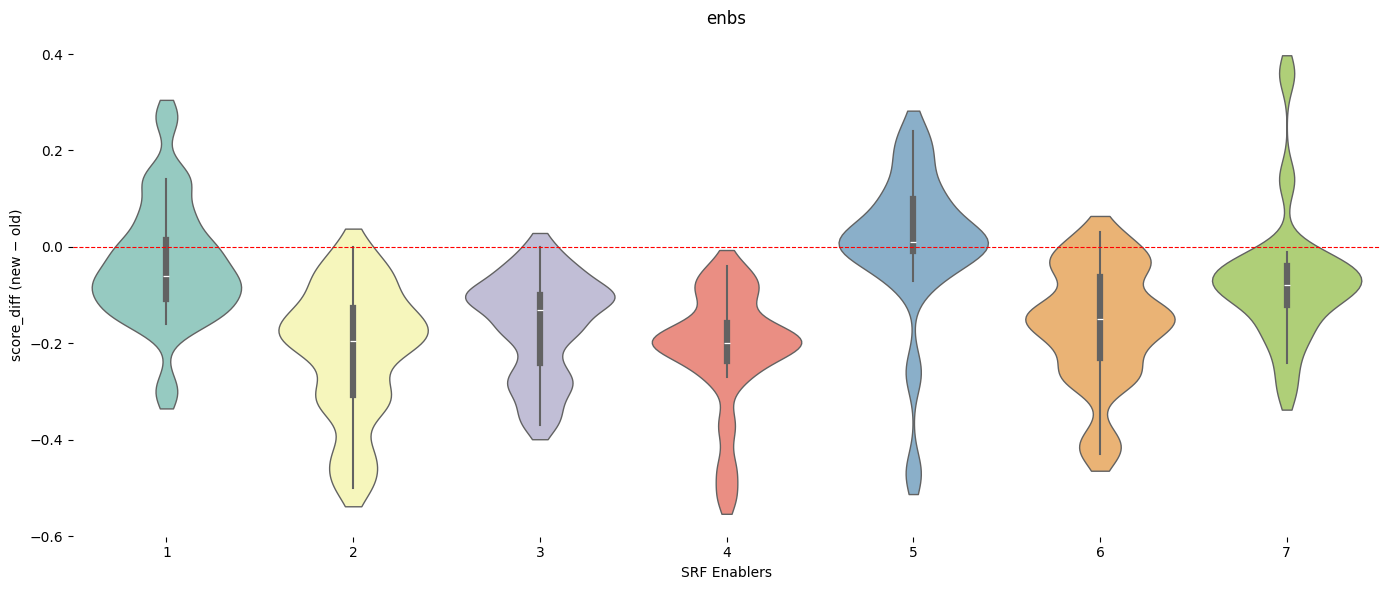

In [ ]:
plot_score_diffs(dfs, 'enbs', 'SRF Enablers')

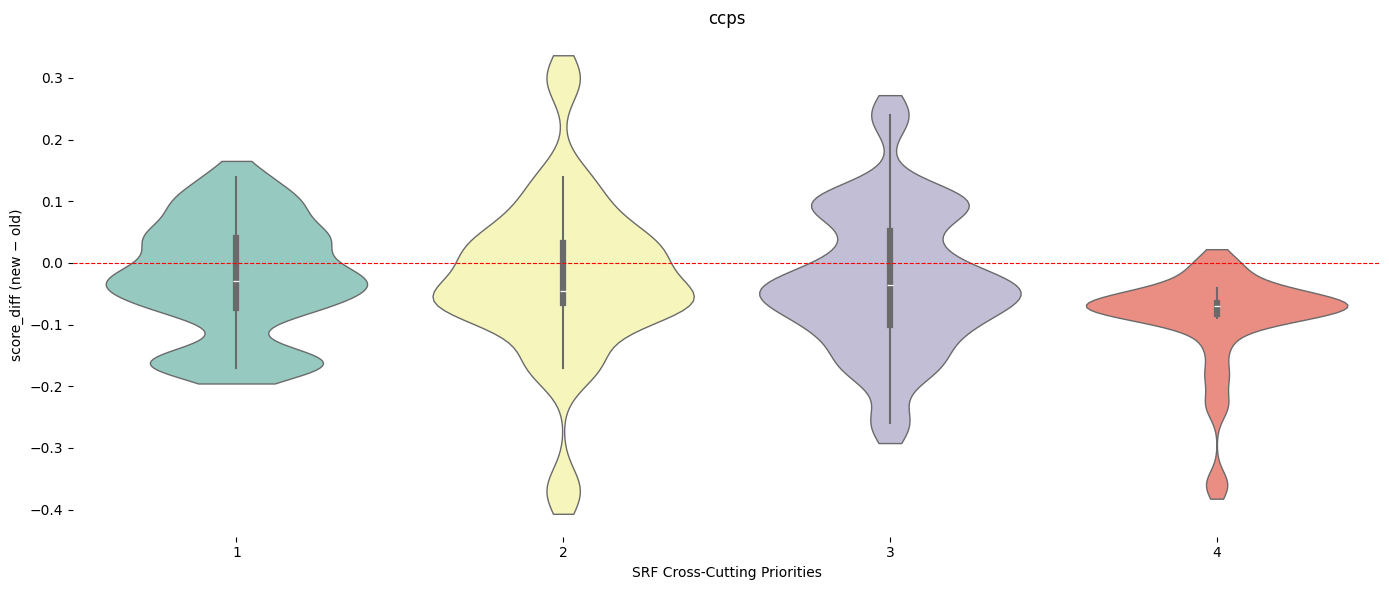

In [ ]:
plot_score_diffs(dfs, 'ccps', 'SRF Cross-Cutting Priorities')

In [ ]:
dfs.columns

Index(['mapping_type', 'theme_id', 'theme_title_x', 'score_old',
       'theme_title_y', 'score_new', 'score_diff', 'is_new', 'is_dropped',
       'rank_old', 'rank_new', 'rank_diff', 'pct_change'],
      dtype='str')

### Ranks diff

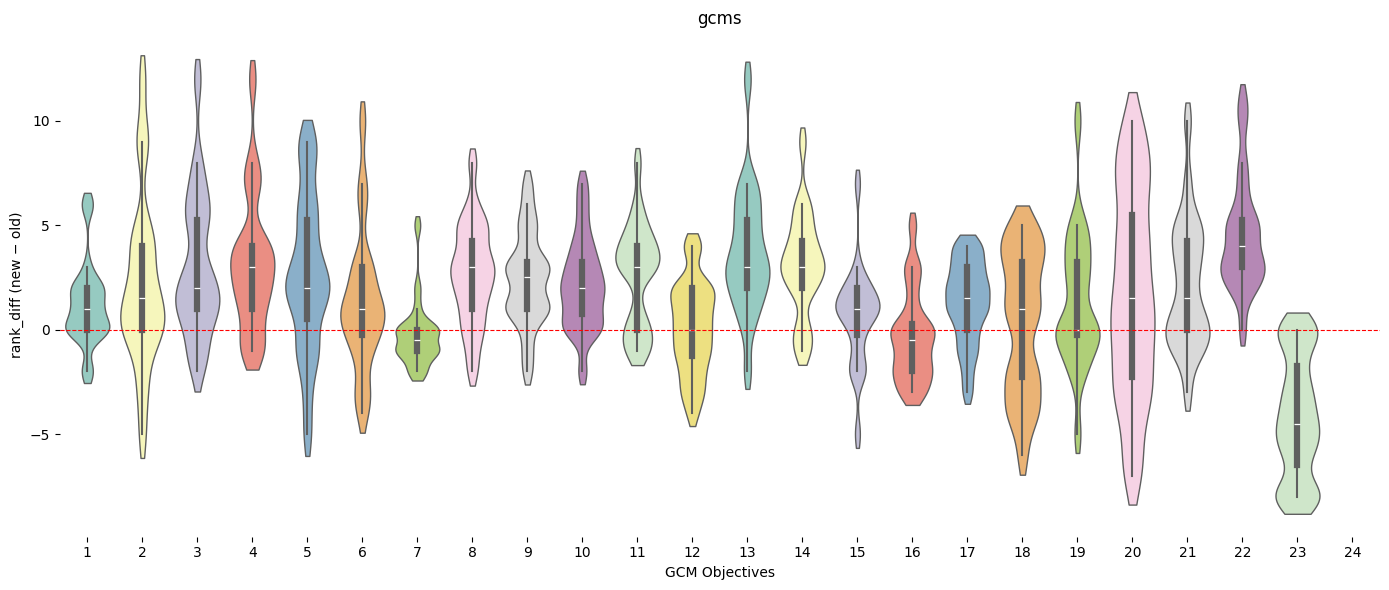

In [ ]:
plot_score_diffs(dfs, 'gcms', 'GCM Objectives', col='rank_diff')

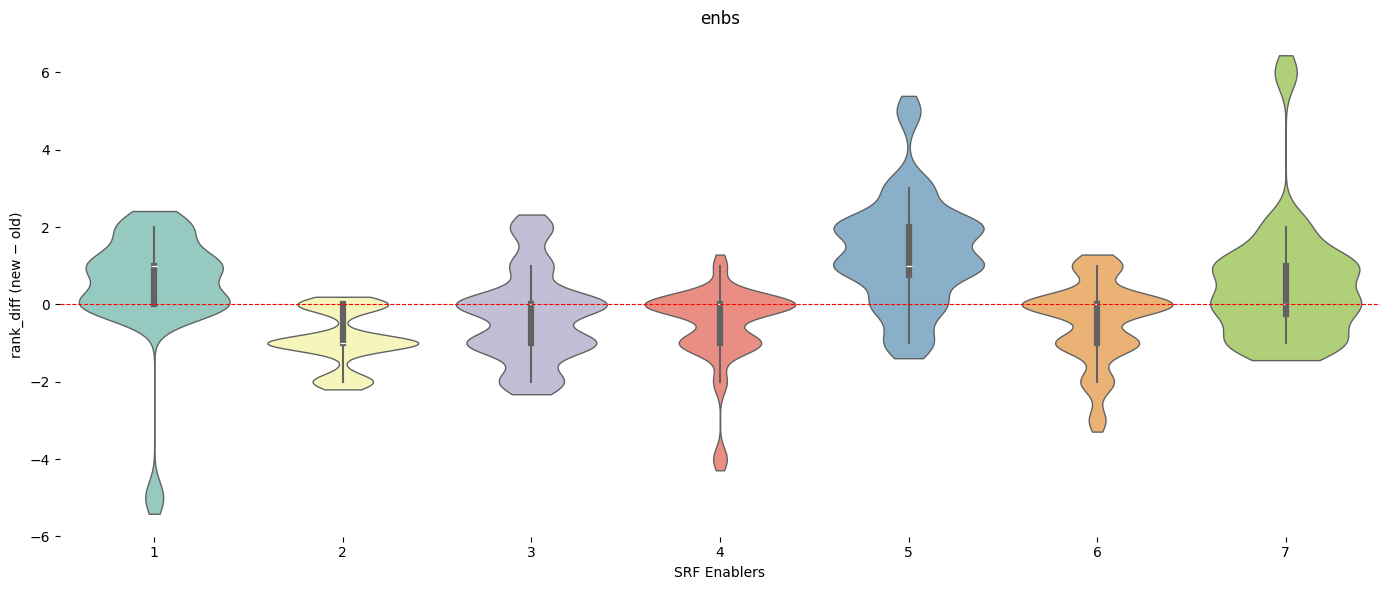

In [ ]:
plot_score_diffs(dfs, 'enbs', 'SRF Enablers', col='rank_diff')

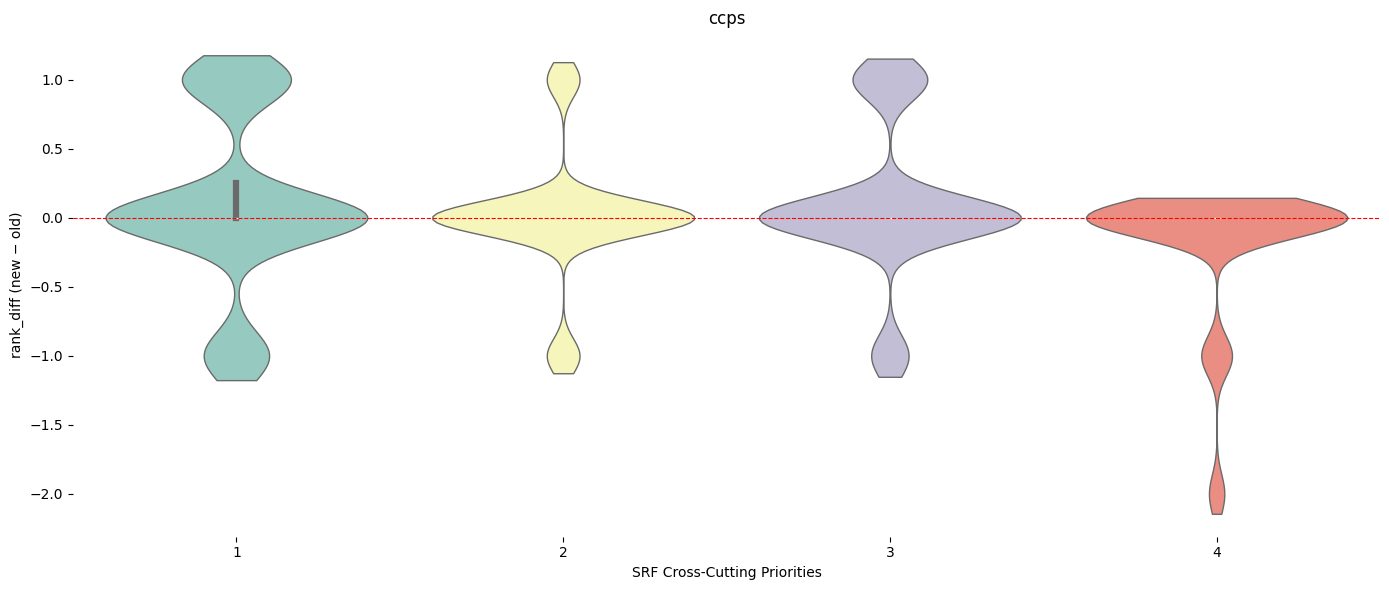

In [ ]:
plot_score_diffs(dfs, 'ccps', 'SRF Cross-Cutting Priorities', col='rank_diff')

In [ ]:
plot_score_diffs(dfs[dfs.rank_old <= 3], 'gcms', 'GCM Objectives', col='rank_diff')

Let's try to answer this question: How often does the top-ranked theme change between old and new?

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

We need to track, per report and mapping type, whether the top-ranked theme changed. We'll need an `eval_id` column first — let me rebuild `dfs` with that, then answer the question.

```python
dfs = pd.concat([
    compare_mappings(d, DATA_PATH/'results', LATEST_TAG_PATH).pipe(add_diffs).pipe(add_ranks).pipe(add_pct_change).assign(eval_id=d)
    for d in current_res], ignore_index=True)
```

Then:

```python
def top_theme(df, rank_col): return df[df[rank_col]==1].set_index(['eval_id','mapping_type'])['theme_id']

top_old = top_theme(dfs, 'rank_old')
top_new = top_theme(dfs, 'rank_new')
top_changed = (top_old != top_new).rename('changed')
top_changed.groupby('mapping_type').mean().mul(100).round(1).rename('% reports where top theme changed')
```

In [ ]:
dfs = pd.concat([
    compare_mappings(d, DATA_PATH/'results', LATEST_TAG_PATH).pipe(add_diffs).pipe(add_ranks).pipe(add_pct_change).assign(eval_id=d)
    for d in current_res], ignore_index=True)

In [ ]:
def top_theme(df, rank_col): return df[df[rank_col]==1].set_index(['eval_id','mapping_type'])['theme_id']

top_old = top_theme(dfs, 'rank_old')
top_new = top_theme(dfs, 'rank_new')
top_changed = (top_old != top_new).rename('changed')
top_changed.groupby('mapping_type').mean().mul(100).round(1).rename('% reports where top theme changed')

mapping_type
ccps    20.0
enbs    55.0
gcms    25.0
outs    20.0
Name: % reports where top theme changed, dtype: float64

### Reports and mapping type where top ranked theme changed

In [ ]:
print(top_changed[top_changed].reset_index()[['eval_id','mapping_type']].sort_values('mapping_type'))

                             eval_id mapping_type
20  4c04ec0d3e651f7616190c6fc2dcfc18         ccps
5   22cac1c000836253adc445993e101560         ccps
18  891448b7a4bf12763ea0579dd67e289d         ccps
15  dba9eb1220368d28682d8531108e767d         ccps
0   8dd2261100ff5d714e73b411eed043d5         enbs
1   1d7e6d2d445145d1d350b48b72b36681         enbs
2   760568a15e144bcfb88dbbd50247dc51         enbs
21  e21305a89aeb76fafa8f4270392d463a         enbs
17  06fd0949dc874f388686461c19d2669c         enbs
8   316c47c9dc19c820f3217434d4b93b28         enbs
16  a493c447cff3e03ca94024335d5c5c7a         enbs
10  0d4309b702e00faac631be8d609934ce         enbs
12  e8d9427f4a9094f68e17307faa567d8b         enbs
13  75bad4665ed458cce78740e3d86f72d0         enbs
14  f409b3f9a0671ec69a8591c425a45c1d         enbs
11  0d4309b702e00faac631be8d609934ce         gcms
9   316c47c9dc19c820f3217434d4b93b28         gcms
6   22cac1c000836253adc445993e101560         gcms
3   760568a15e144bcfb88dbbd50247dc51         gcms


In [ ]:
def plot_rank_changes(df):
    "Slope chart of rank changes (old → new) per mapping type, coloured by direction"
    fig, axes = plt.subplots(1, df.mapping_type.nunique(), figsize=(20, 8), sharey=False)
    for ax, (mt, grp) in zip(axes, df.groupby('mapping_type')):
        for _, row in grp.iterrows():
            color = 'steelblue' if row.rank_diff < 0 else '#d9534f' if row.rank_diff > 0 else 'grey'
            ax.plot([0, 1], [row.rank_old, row.rank_new], marker='o', color=color, alpha=0.7)
            ax.text(0.5, (row.rank_old + row.rank_new) / 2 + (-0.15 * row.rank_diff), row.theme_id,
                    ha='center', va='center', fontsize=8, fontweight='bold', color=color,
                    path_effects=[withStroke(linewidth=3, foreground='white')])
        ax.set_xticks([0, 1])
        ax.set_xticklabels(['Old', 'New'], fontsize=12)
        ax.invert_yaxis()
        ax.set_title(mt, fontsize=14, fontweight='bold')
        ax.set_ylabel('Rank', fontsize=12)
    plt.tight_layout()
    plt.show()

In [ ]:
#dfs[dfs.eval_id == '0d4309b702e00faac631be8d609934ce']

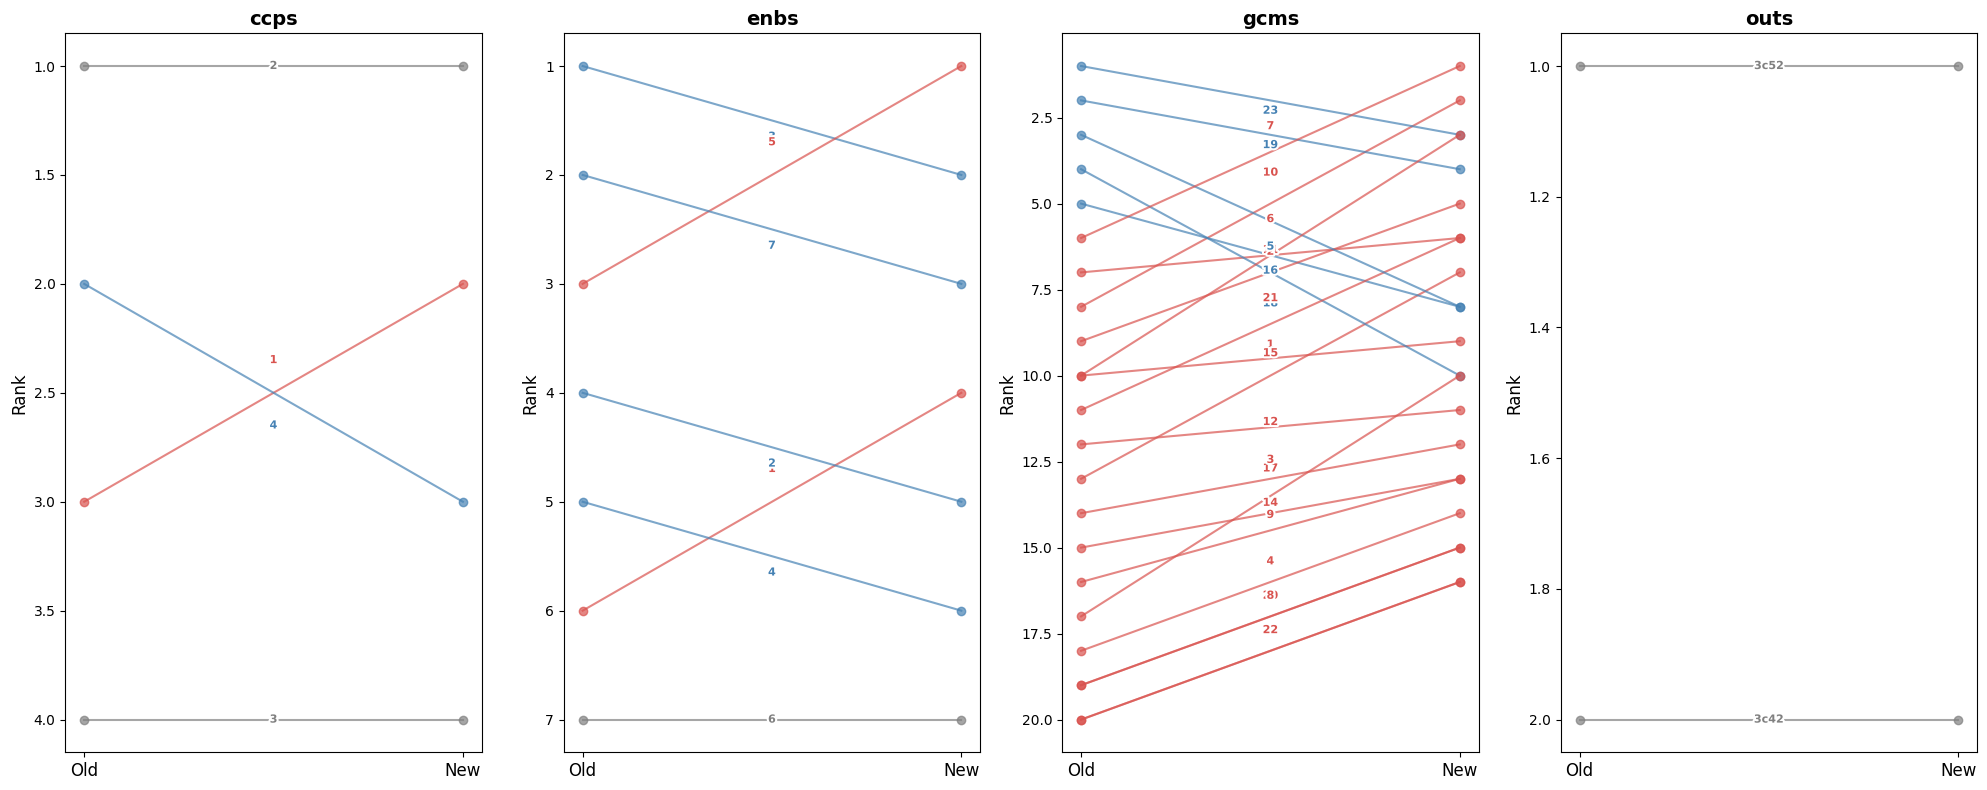

In [ ]:
plot_rank_changes(dfs[dfs.eval_id == '0d4309b702e00faac631be8d609934ce'])

In [ ]:
def plot_score_diffs_bar(df):
    "Bar chart of score diffs (new − old) per theme, coloured by direction, faceted by mapping type"
    fig, axes = plt.subplots(1, df.mapping_type.nunique(), figsize=(20, 8), sharey=False)
    for ax, (mt, grp) in zip(axes, df.groupby('mapping_type')):
        ax.barh(grp.theme_id.astype(str), grp.score_diff, color=['#d9534f' if x > 0 else 'steelblue' for x in grp.score_diff])
        ax.axvline(0, color='black', linewidth=0.8)
        ax.set(title=mt, xlabel='Score diff', ylabel='Theme ID')
    plt.tight_layout()
    plt.show()

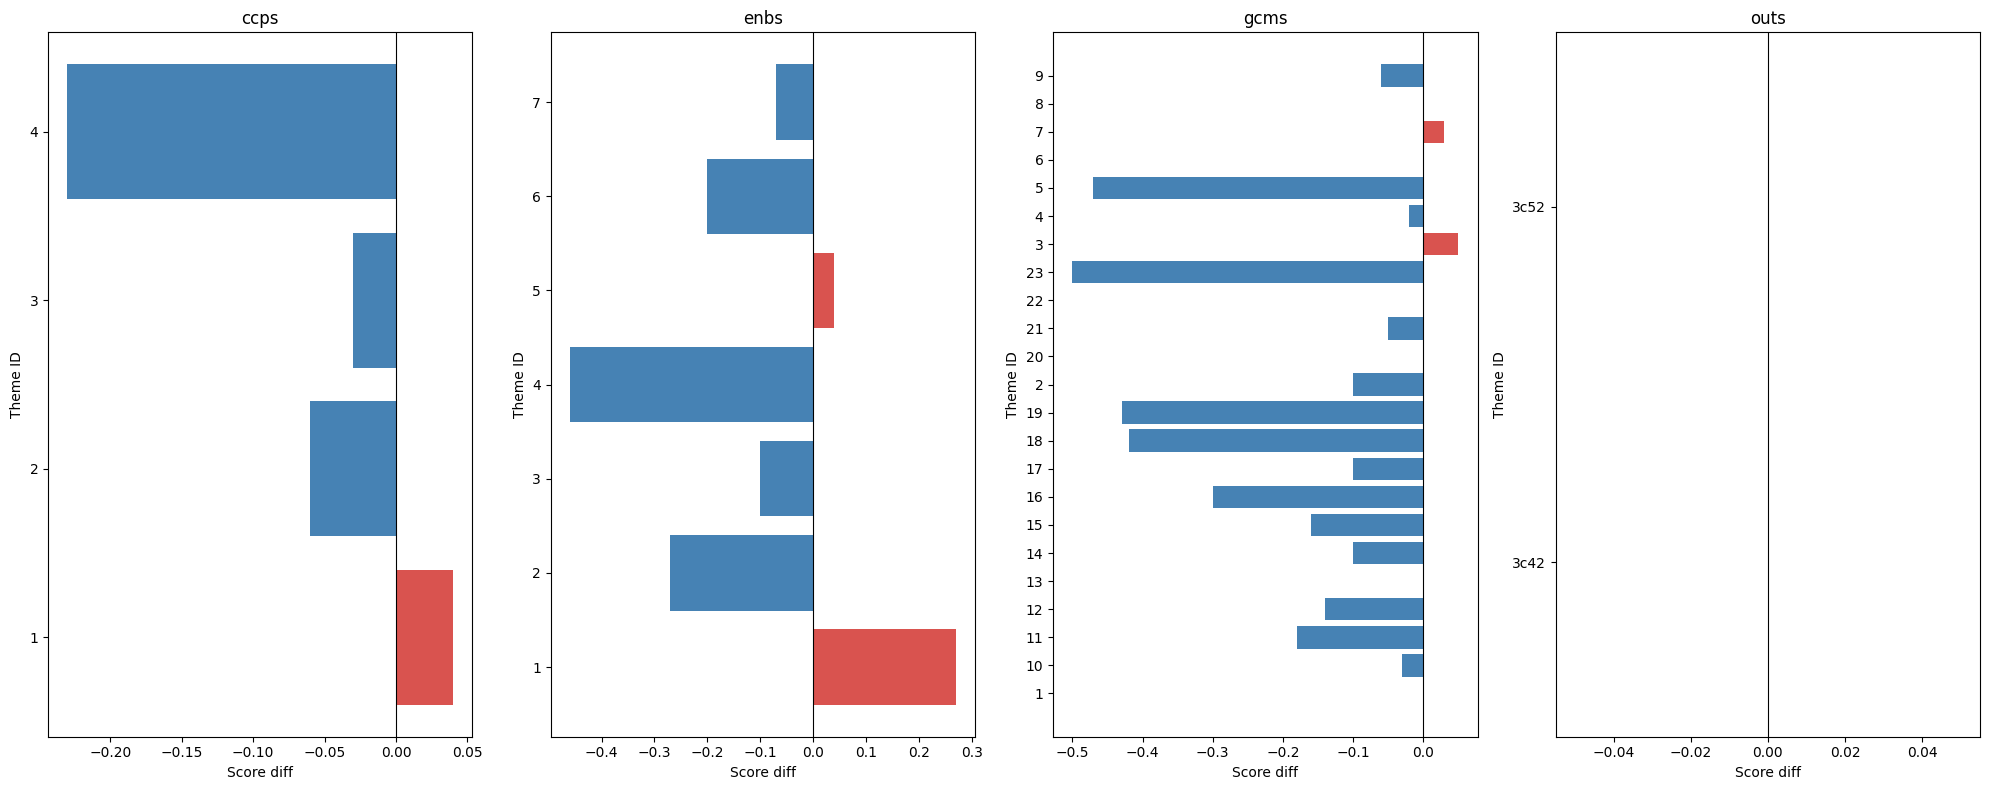

In [ ]:
plot_score_diffs_bar(dfs[dfs.eval_id == '0d4309b702e00faac631be8d609934ce'])

In [ ]:
def plot_scores_comparison(df, eval_id, mapping_type):
    "Grouped bar chart of old vs new scores per theme for a given report and mapping type"
    title = info_eval(eval_id).meta['Title']
    title_pretty = title if len(title) < 80 else title[:80] + '...'
    d = df[(df.eval_id==eval_id) & (df.mapping_type==mapping_type)].copy()
    d['theme_id'] = d['theme_id'].astype(int)
    d = d.sort_values('theme_id')
    x = range(len(d))
    f, ax = plt.subplots(figsize=(14, 5))
    ax.bar([i-0.2 for i in x], d.score_old, width=0.4, label='old', color='steelblue', alpha=0.8)
    ax.bar([i+0.2 for i in x], d.score_new, width=0.4, label='new', color='#d9534f', alpha=0.8)
    ax.set_xticks(list(x))
    ax.set_xticklabels(d.theme_id)
    ax.set(xlabel='Theme ID', ylabel='Score', title=f'{mapping_type} — {title_pretty}')
    ax.legend()
    plt.tight_layout()

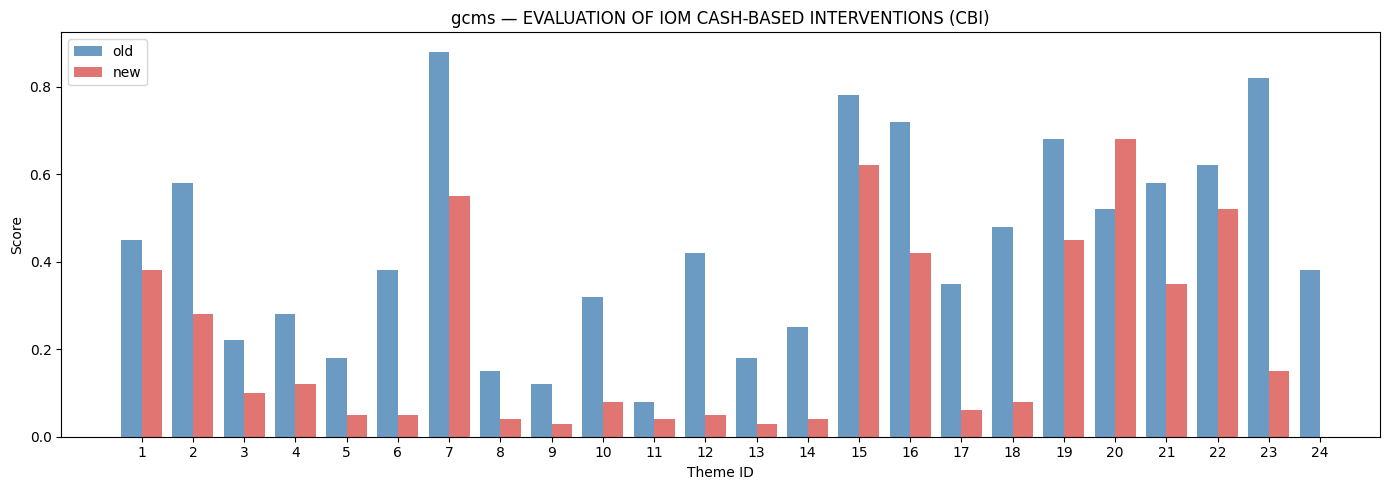

In [ ]:
plot_scores_comparison(dfs, '316c47c9dc19c820f3217434d4b93b28', 'gcms')

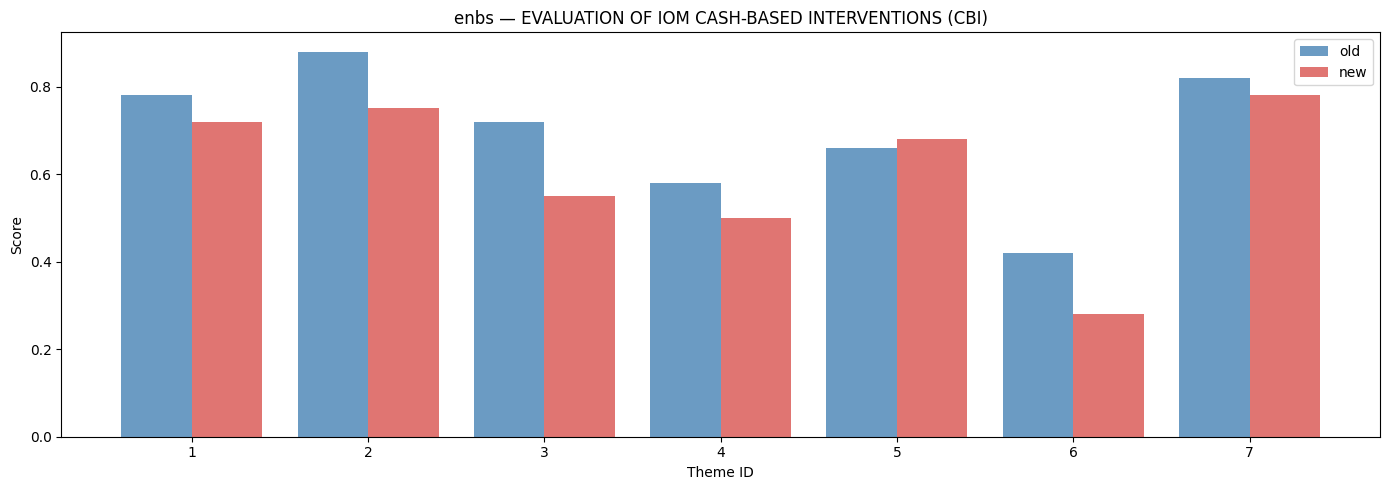

In [ ]:
plot_scores_comparison(dfs, '316c47c9dc19c820f3217434d4b93b28', 'enbs')

In [ ]:
df_top_changed = top_changed[top_changed].reset_index()[['eval_id','mapping_type']]

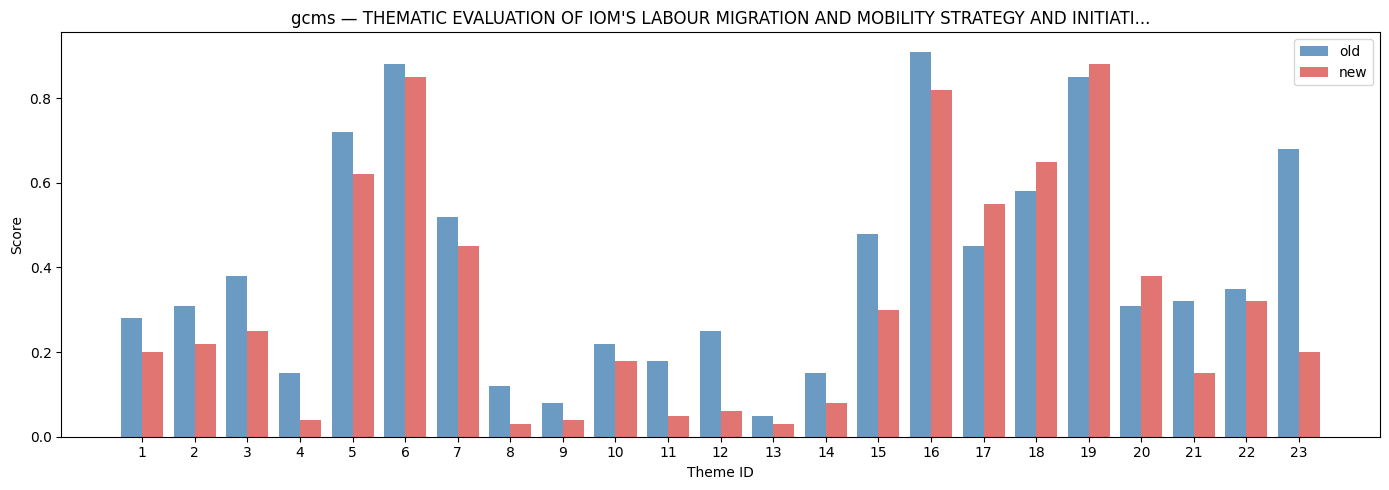

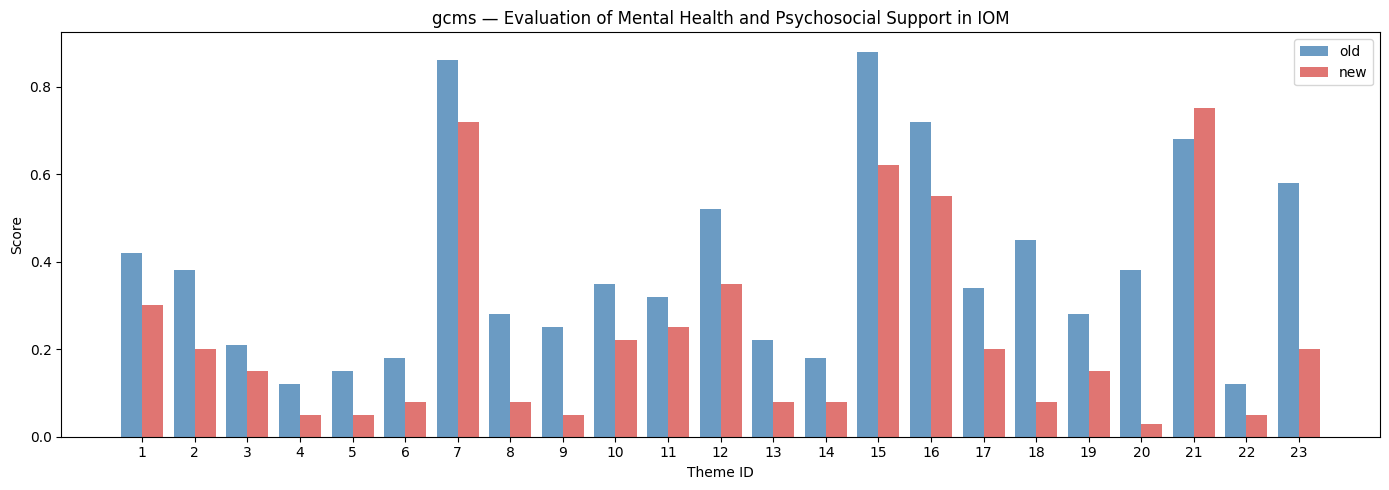

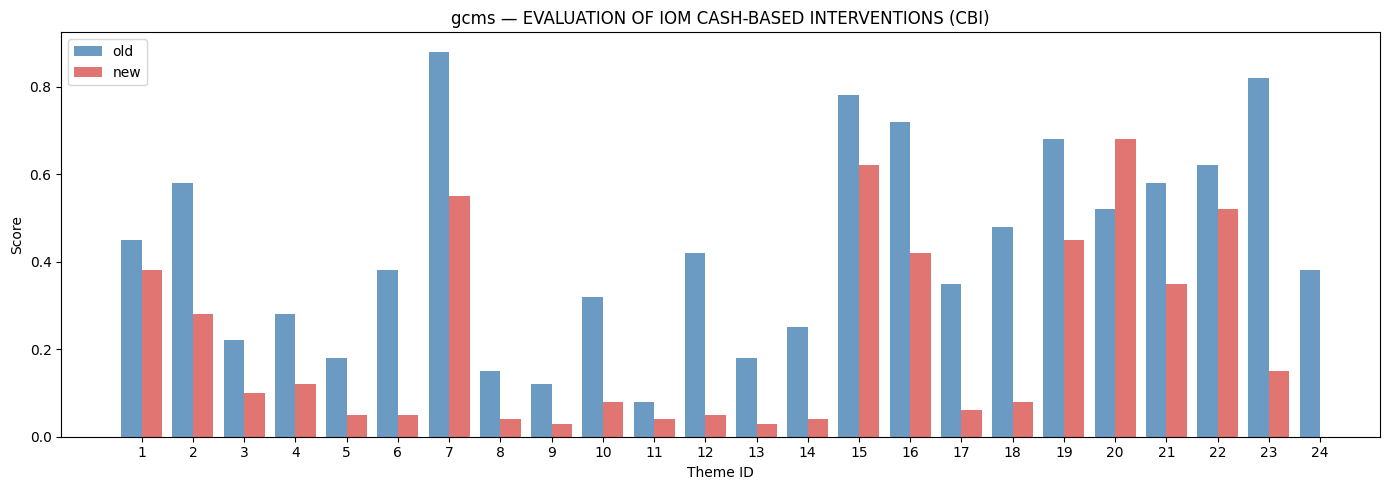

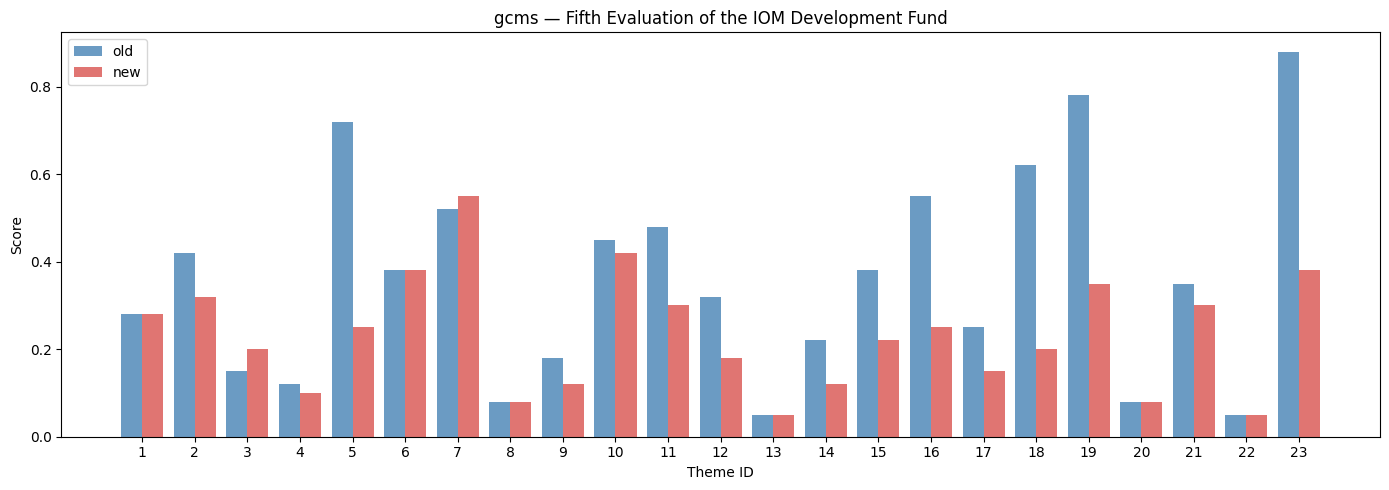

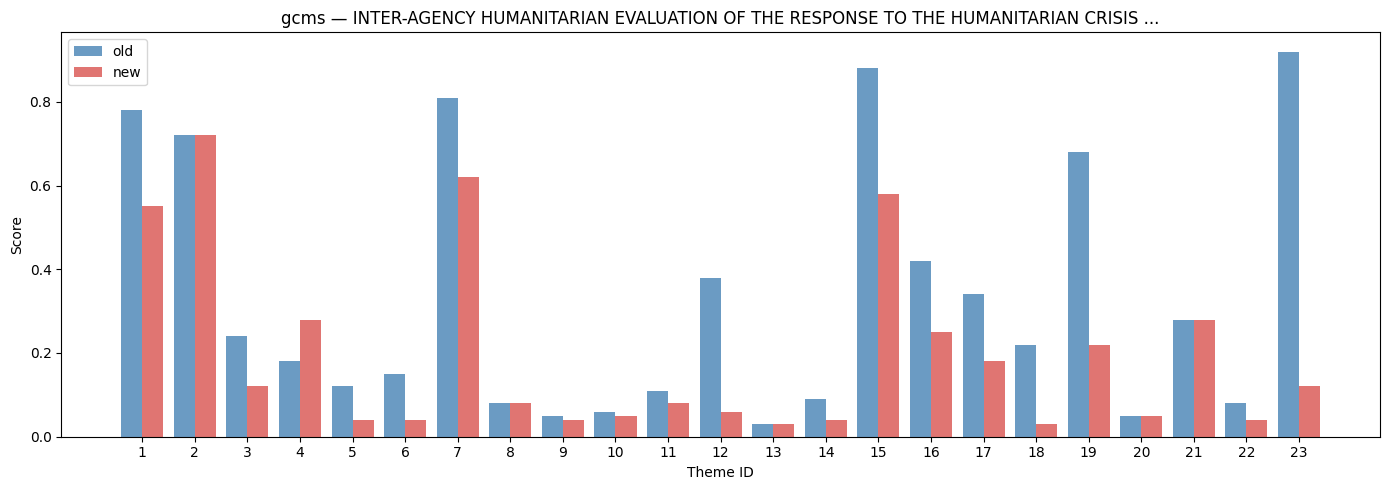

In [ ]:
for id_ in df_top_changed[df_top_changed.mapping_type == 'gcms'].eval_id:
    plot_scores_comparison(dfs, id_, 'gcms')

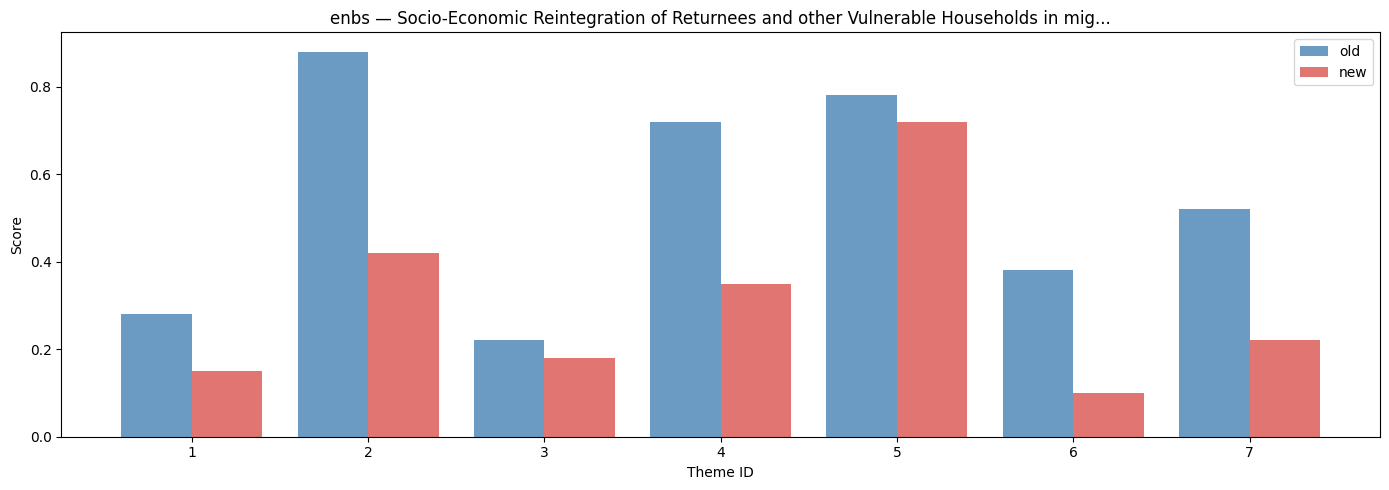

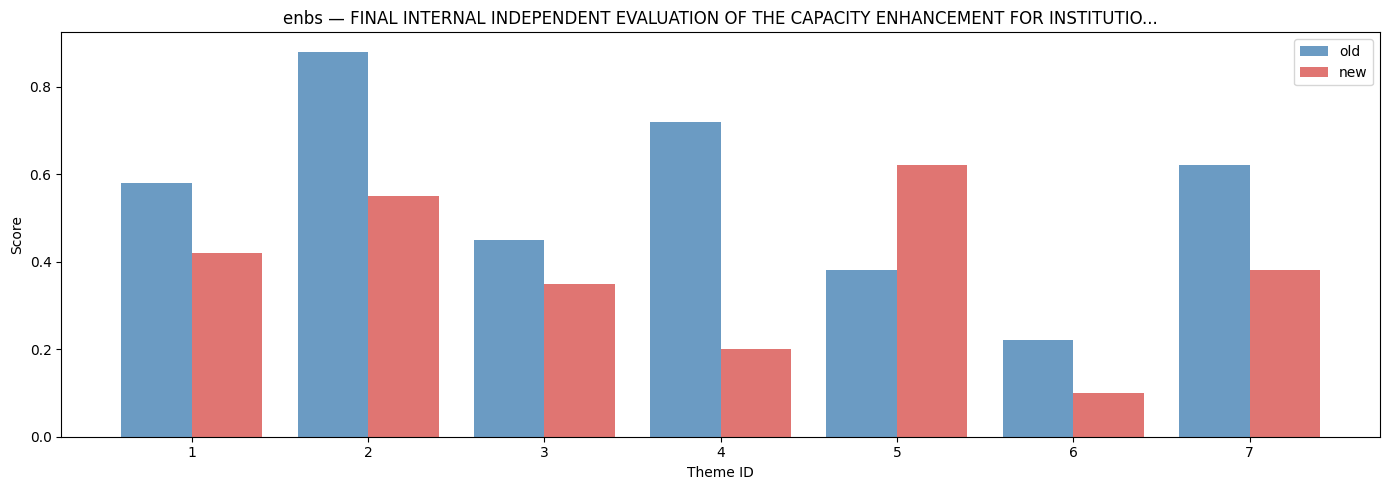

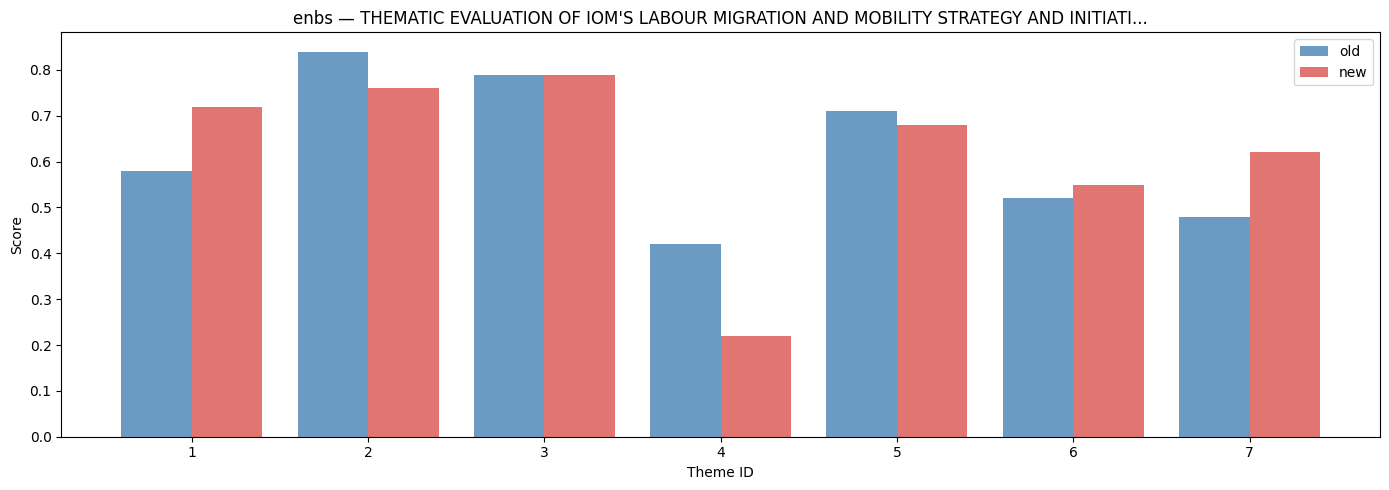

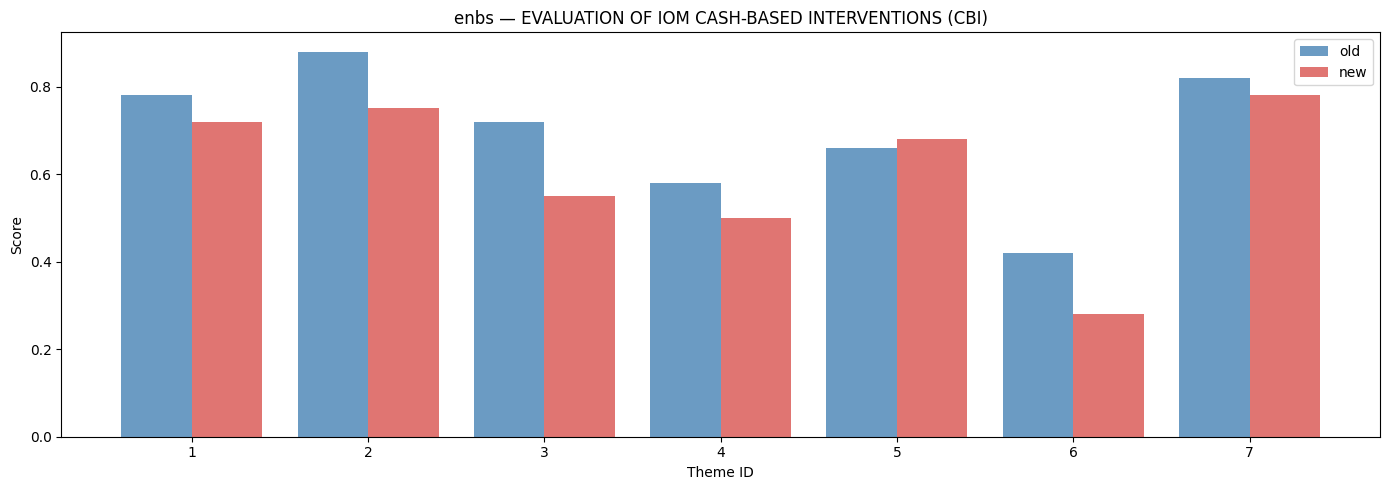

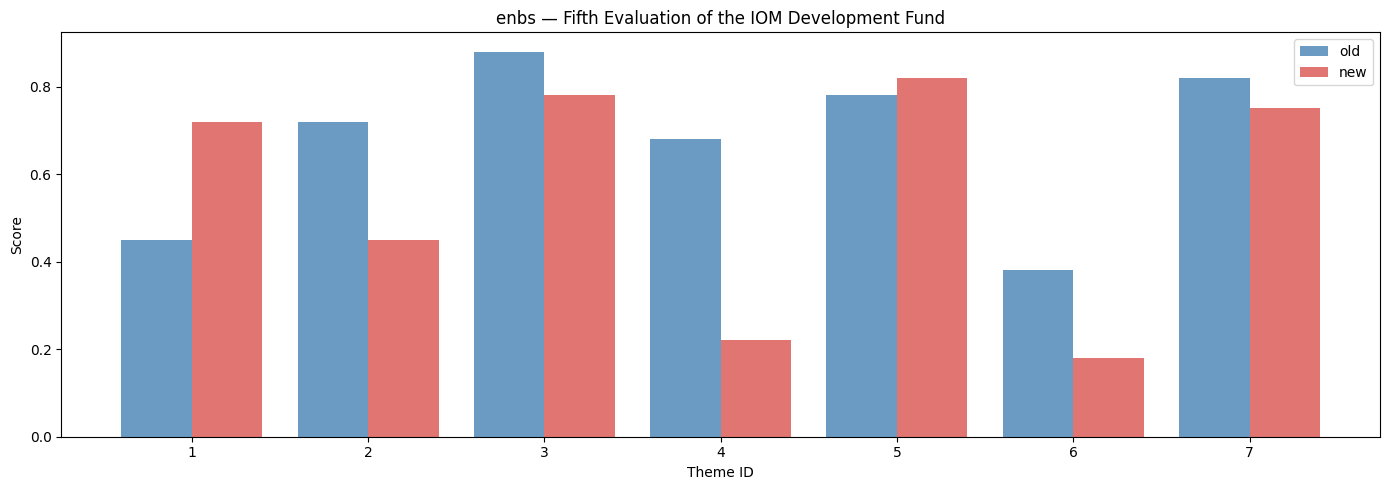

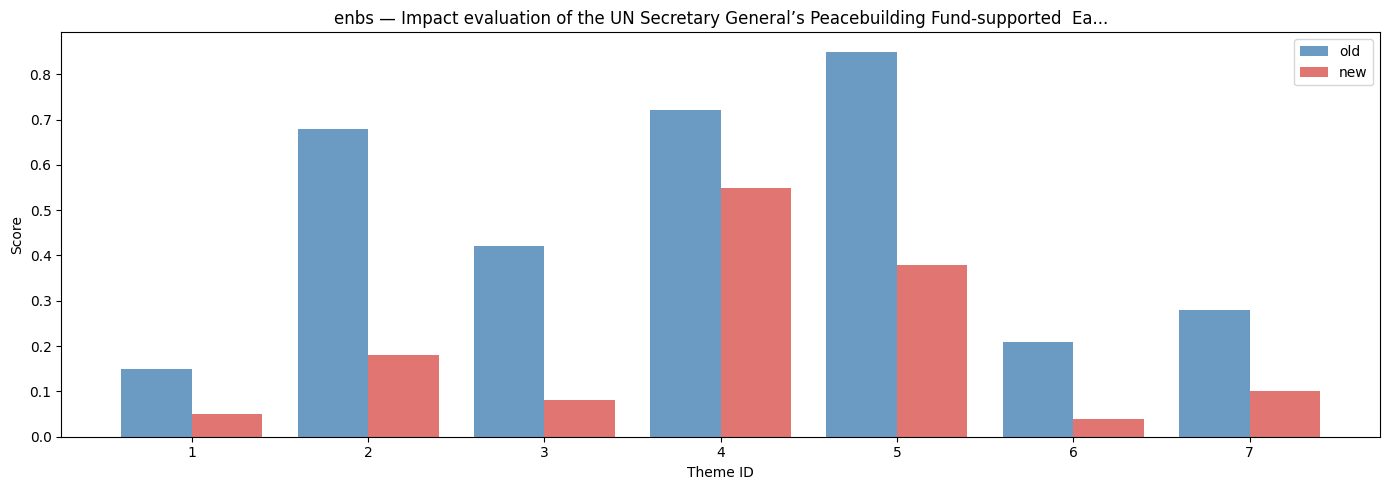

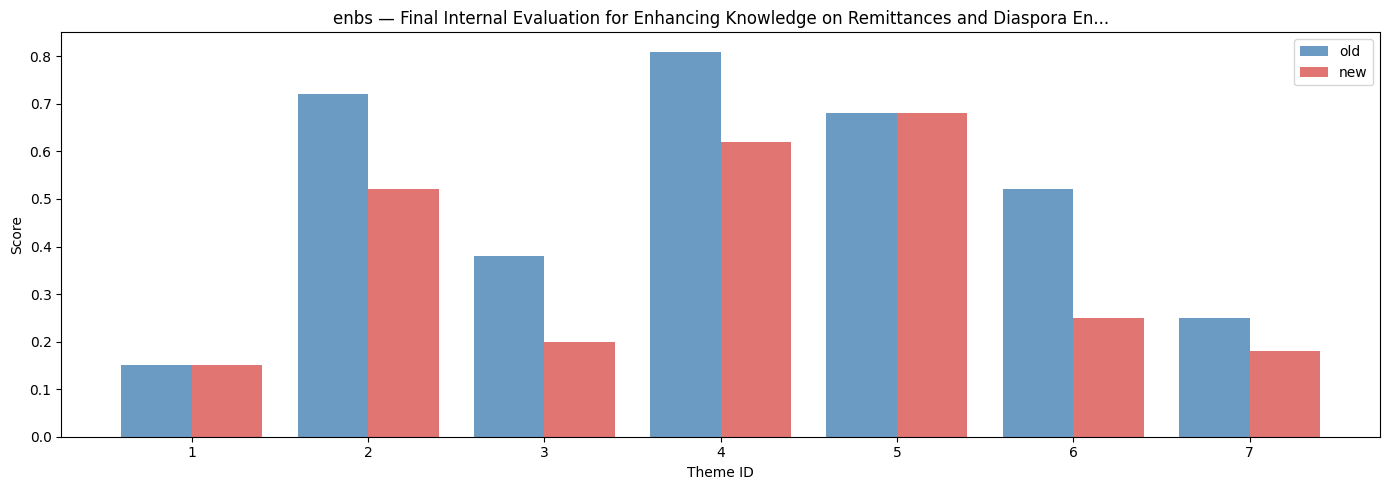

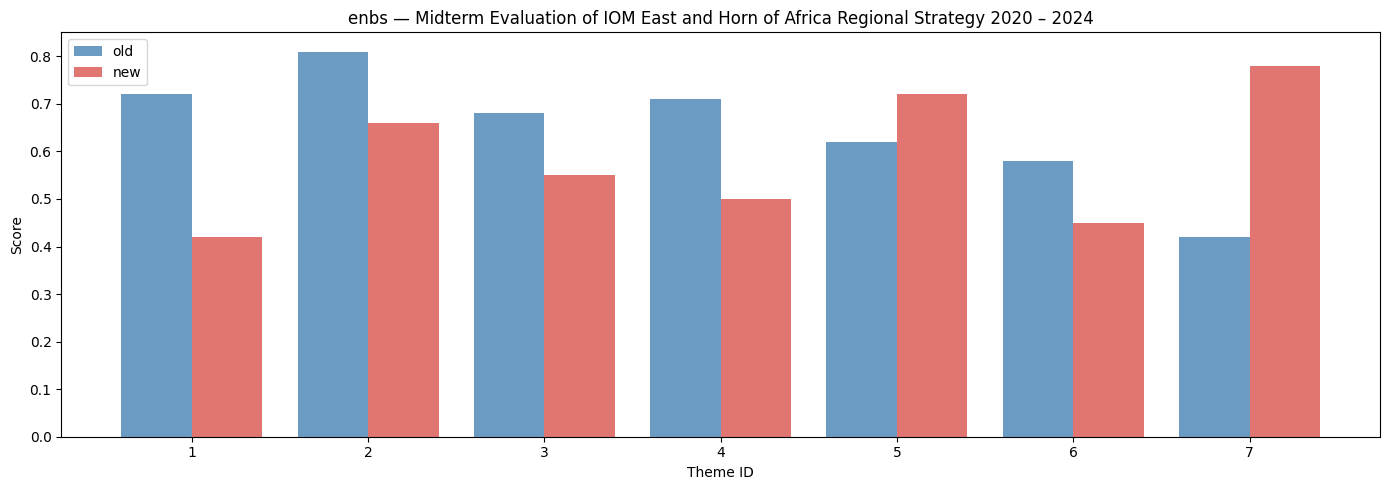

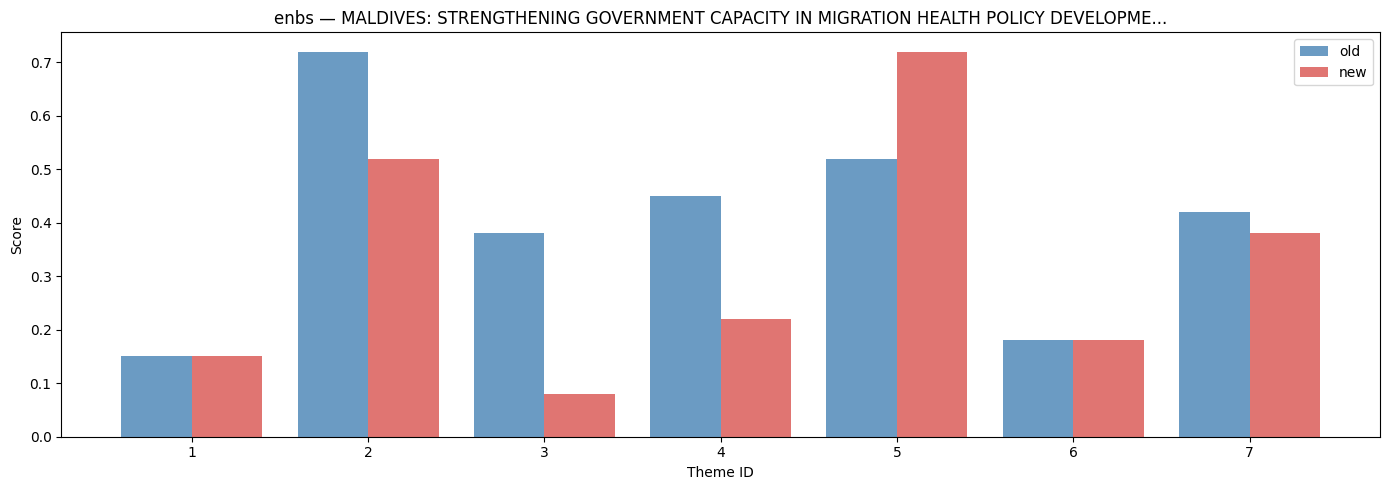

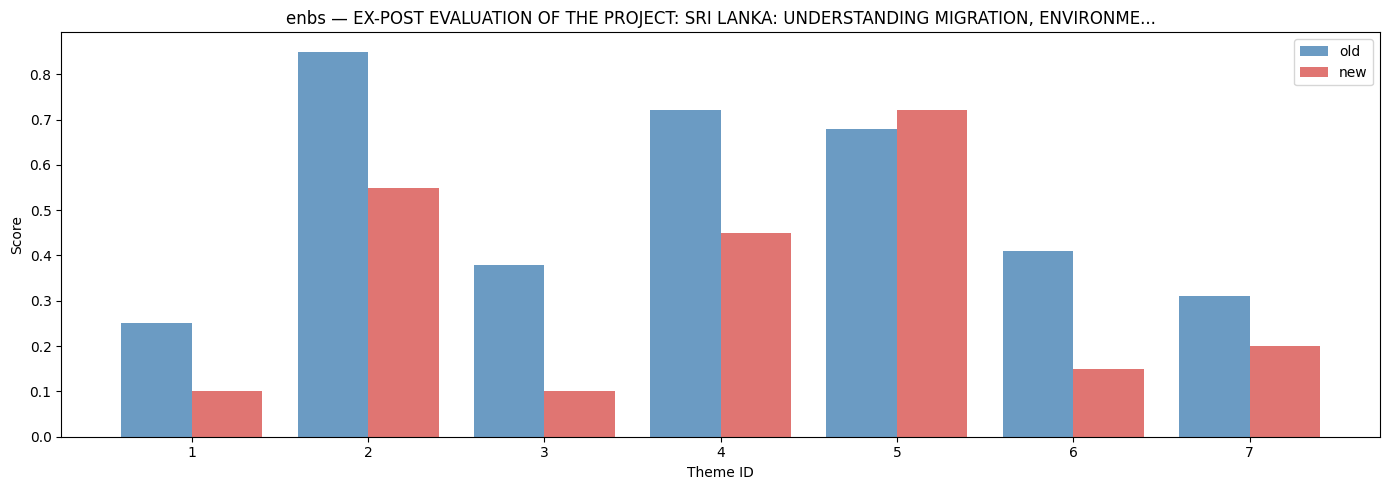

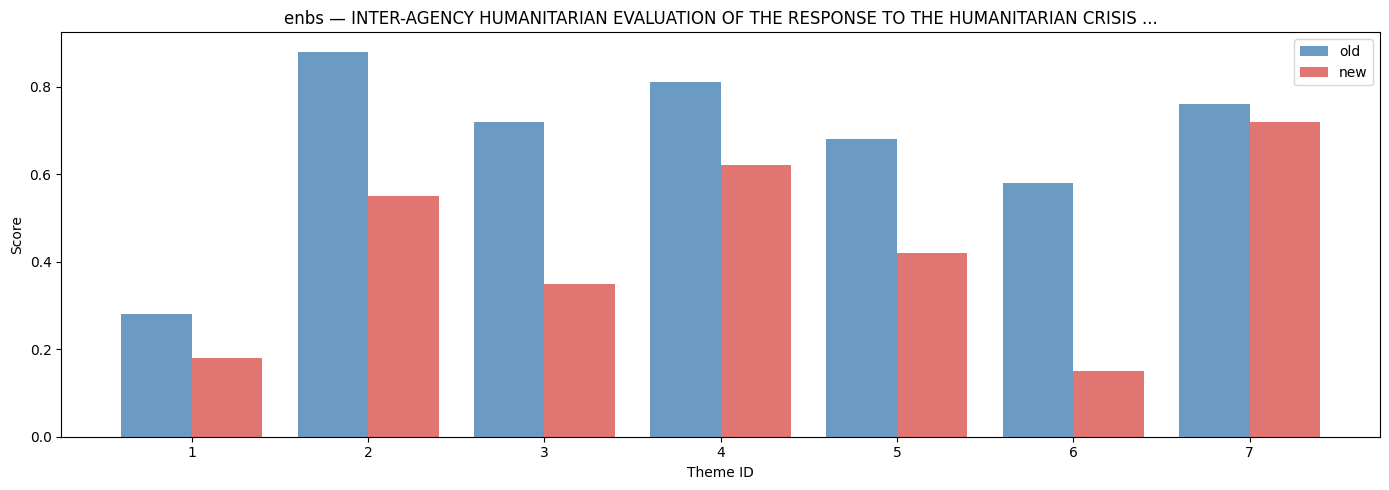

In [ ]:
for id_ in df_top_changed[df_top_changed.mapping_type == 'enbs'].eval_id:
    plot_scores_comparison(dfs, id_, 'enbs')



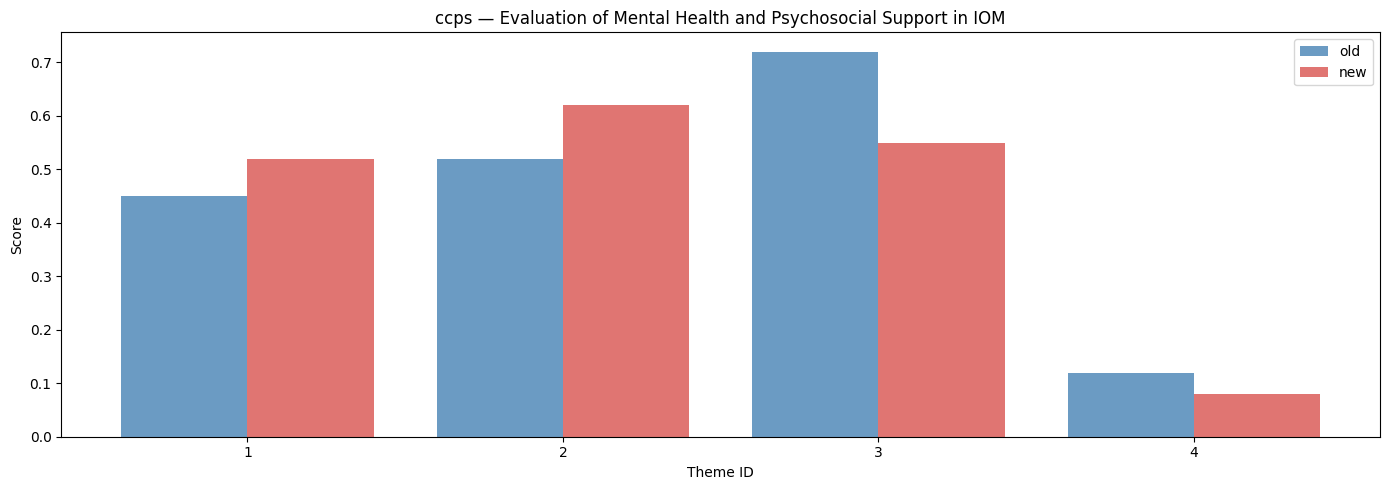

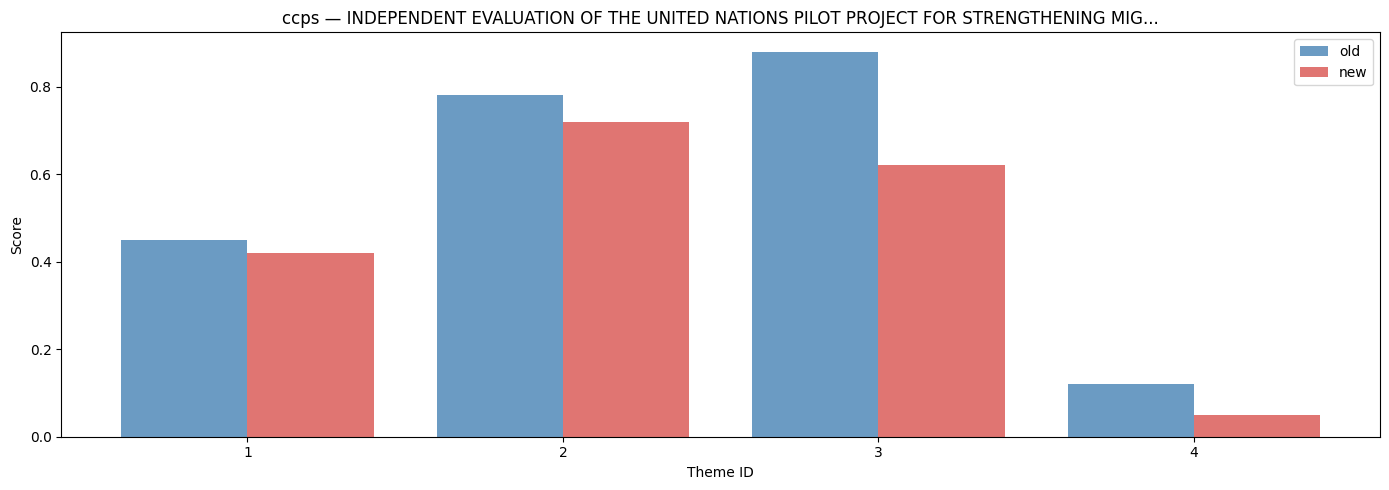

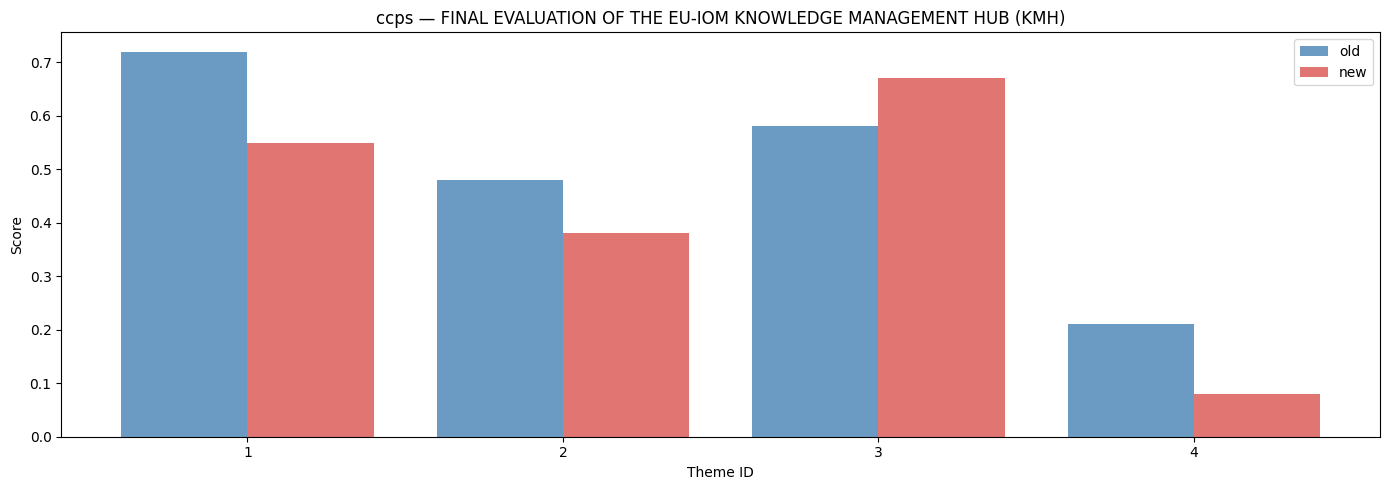

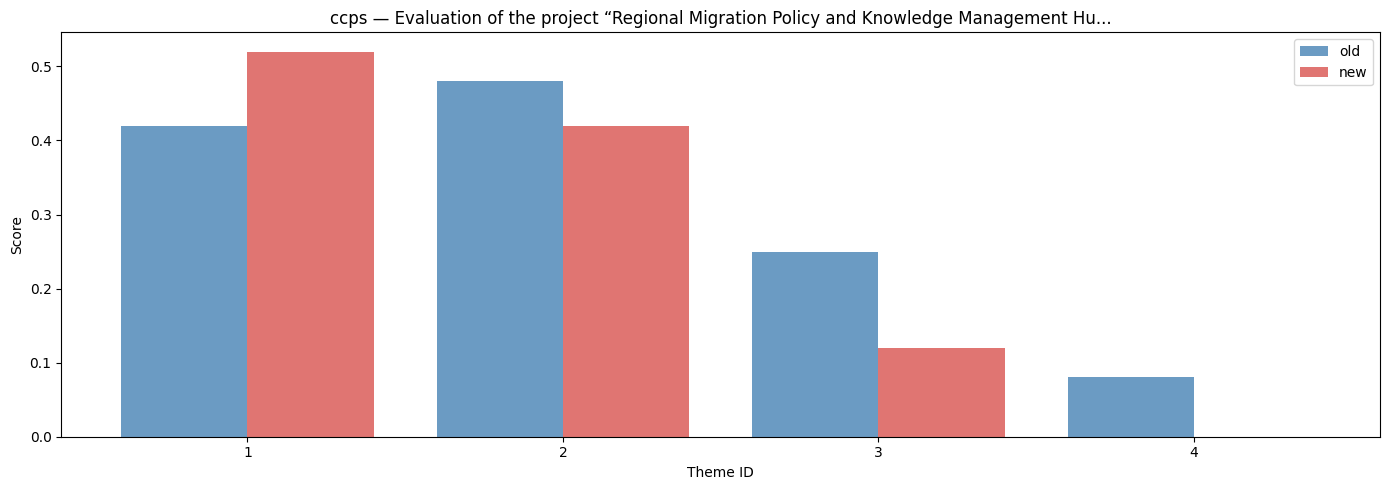

In [ ]:
for id_ in df_top_changed[df_top_changed.mapping_type == 'ccps'].eval_id:
    plot_scores_comparison(dfs, id_, 'ccps')